In [142]:
import pandas as pd
import numpy as np
import datetime
import sys
import copy
import os
#from WindPy import w
import scipy.io as scio
from scipy.stats.mstats import winsorize
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import os
from scipy.stats import spearmanr
from scipy.stats import ttest_1samp
import statsmodels.api as sm
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['SimHei']  # 用 SimHei 替换为合适的中文字体
rcParams['axes.unicode_minus'] = False  # 解决坐标轴负号显示问题

In [143]:
ETF=pd.read_csv(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\ETF.csv', index_col=0)
ETF.rename(columns={'UnitNV':'UnitNVRestored'},inplace=True)
ETF.drop_duplicates(subset=['SecuCode','TradingDay','EndShares'],keep='last',inplace=True)
ETF.drop_duplicates(subset=['SecuCode','TradingDay','UnitNVRestored'],keep='last',inplace=True)
ETF

,SecuCode,TradingDay,UnitNVRestored,EndDate,EndShares,FloatShares
2,000001.OF,2012-12-31,0.9610,2012-12-31,9.373216e+09,NaN
4,000001.OF,2013-03-31,1.0240,2013-03-31,9.093381e+09,NaN
7,000001.OF,2013-06-30,1.0120,2013-06-30,8.775370e+09,NaN
9,000001.OF,2013-09-30,1.1310,2013-09-30,8.294967e+09,NaN
12,000001.OF,2013-12-31,1.1120,2013-12-31,8.008907e+09,NaN
...,...,...,...,...,...,...
3618931,980003.OF,2022-06-30,1.5393,2022-06-30,2.352391e+09,NaN
3618933,980003.OF,2022-09-30,1.5513,2022-09-30,2.325806e+09,NaN
3618936,980003.OF,2022-12-31,1.5497,2022-12-31,1.825143e+09,NaN
3618938,980003.OF,2023-03-31,1.5666,2023-03-31,1.265889e+09,NaN


In [144]:
name=pd.read_excel(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\宽基ETF名单.xlsx',sheet_name='宽基')
name['二级分类']=name['跟踪指数代码']
name['四级分类']=name['二级分类']
name

,跟踪指数代码,证券代码,证券简称,成立日期,按交易方式分类,一级分类,二级分类,四级分类
0,000016,563090.OF,易方达上证50增强策略ETF,2024-05-27,ETF,量化-增强被动指数型,000016,000016
1,000300,561300.OF,国泰沪深300增强策略ETF,2021-12-01,ETF,量化-增强被动指数型,000300,000300
2,000300,561990.OF,招商沪深300增强策略ETF,2021-12-02,ETF,量化-增强被动指数型,000300,000300
3,000300,561000.OF,华安沪深300增强策略ETF,2022-12-21,ETF,量化-增强被动指数型,000300,000300
4,000688,588370.OF,南方上证科创板50成份增强策略ETF,2022-12-01,ETF,量化-增强被动指数型,000688,000688
...,...,...,...,...,...,...,...,...
227,000510,563360.OF,华泰柏瑞中证A500ETF,2024-09-25,ETF,量化-普通被动指数型,000510,000510
228,000510,560610.SH,招商中证A500ETF,2024-09-26,ETF,量化-普通被动指数型,000510,000510
229,000510,159338.SZ,国泰中证A500ETF,2024-09-26,ETF,量化-普通被动指数型,000510,000510
230,000510,159339.SZ,银华中证A500ETF,2024-09-26,ETF,量化-普通被动指数型,000510,000510


In [145]:
ETF.rename(columns={'SecuCode':'证券代码'},inplace=True)
merged=pd.merge(ETF,name,on='证券代码',how='inner')
merged.sort_values(by=['证券代码','TradingDay'])
hangye=merged.copy()
hangye['EndShares'] = hangye.apply(lambda row: row['FloatShares'] if pd.isna(row['EndShares']) else row['EndShares'], axis=1)
hangye = hangye.dropna(subset=['EndShares', 'FloatShares'], how='all')
hangye 

,证券代码,TradingDay,UnitNVRestored,EndDate,EndShares,FloatShares,跟踪指数代码,证券简称,成立日期,按交易方式分类,一级分类,二级分类,四级分类
0,159150.OF,2023-12-04,0.9996,2023-12-04,2.600998e+09,NaN,399850,易方达深证50ETF,2023-11-29,ETF,量化-普通被动指数型,399850,399850
1,159150.OF,2023-12-11,1.0046,2023-12-11,2.600998e+09,2.600998e+09,399850,易方达深证50ETF,2023-11-29,ETF,量化-普通被动指数型,399850,399850
2,159150.OF,2023-12-12,1.0037,2023-12-12,1.917998e+09,1.917998e+09,399850,易方达深证50ETF,2023-11-29,ETF,量化-普通被动指数型,399850,399850
3,159150.OF,2023-12-13,0.9859,2023-12-13,1.419998e+09,1.419998e+09,399850,易方达深证50ETF,2023-11-29,ETF,量化-普通被动指数型,399850,399850
4,159150.OF,2023-12-14,0.9796,2023-12-14,1.536998e+09,1.536998e+09,399850,易方达深证50ETF,2023-11-29,ETF,量化-普通被动指数型,399850,399850
...,...,...,...,...,...,...,...,...,...,...,...,...,...
232638,588900.OF,2024-12-25,0.9287,2024-12-25,4.097830e+08,4.097830e+08,000698,南方上证科创板100ETF,2023-12-08,ETF,量化-普通被动指数型,000698,000698
232639,588900.OF,2024-12-26,0.9441,2024-12-26,4.037830e+08,4.037830e+08,000698,南方上证科创板100ETF,2023-12-08,ETF,量化-普通被动指数型,000698,000698
232640,588900.OF,2024-12-27,0.9342,2024-12-27,4.007830e+08,4.007830e+08,000698,南方上证科创板100ETF,2023-12-08,ETF,量化-普通被动指数型,000698,000698
232641,588900.OF,2024-12-30,0.9270,2024-12-30,3.977830e+08,3.977830e+08,000698,南方上证科创板100ETF,2023-12-08,ETF,量化-普通被动指数型,000698,000698


### 覆盖个数

In [146]:
fugai=hangye.copy()
fugai.sort_values(by='TradingDay',inplace=True)
fugai

,证券代码,TradingDay,UnitNVRestored,EndDate,EndShares,FloatShares,跟踪指数代码,证券简称,成立日期,按交易方式分类,一级分类,二级分类,四级分类
43138,159912.OF,2012-12-31,0.8581,2012-12-31,2.511490e+08,NaN,399007,汇添富深证300ETF,2011-09-16,ETF,量化-普通被动指数型,399007,399007
120052,510330.OF,2012-12-31,1.0327,2012-12-31,6.028088e+08,NaN,000300,华夏沪深300ETF,2012-12-25,ETF,量化-普通被动指数型,000300,000300
108380,510210.OF,2012-12-31,2.3570,2012-12-31,1.526385e+08,NaN,000001,富国上证综指ETF,2011-01-30,ETF,量化-普通被动指数型,000001,000001
46069,159915.OF,2012-12-31,0.7160,2012-12-31,6.174549e+08,NaN,399006,易方达创业板ETF,2011-09-20,ETF,量化-普通被动指数型,399006,399006
111311,510290.OF,2012-12-31,0.8043,2012-12-31,2.084489e+08,NaN,000009,南方上证380ETF,2011-09-16,ETF,量化-普通被动指数型,000009,000009
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32870,159901.OF,2024-12-31,2.7700,2024-12-31,2.495435e+09,2.495435e+09,399330,易方达深证100ETF,2006-03-24,ETF,量化-普通被动指数型,399330,399330
35795,159902.OF,2024-12-31,3.3288,2024-12-31,1.354608e+08,1.354608e+08,399005,华夏中小企业100ETF,2006-06-08,ETF,量化-普通被动指数型,399005,399005
222231,588190.OF,2024-12-31,0.8922,2024-12-31,5.353618e+09,5.353618e+09,000698,银华上证科创板100ETF,2023-09-06,ETF,量化-普通被动指数型,000698,000698
199760,515800.OF,2024-12-31,1.0135,2024-12-31,6.148187e+09,6.148187e+09,000906,汇添富中证800ETF,2019-10-08,ETF,量化-普通被动指数型,000906,000906


In [147]:
quarter_to_date = {
    'Q1': '-03-31',
    'Q2': '-06-30',
    'Q3': '-09-30',
    'Q4': '-12-31'
}
fugai['TradingDay'] = pd.to_datetime(fugai['TradingDay'])
fugai['Quarter'] = fugai['TradingDay'].dt.to_period('Q')
fugai['Quarter'] = fugai['Quarter'].astype(str)
fugai['Quarter'] = fugai['Quarter'].apply(lambda x: x[:4] + quarter_to_date[x[4:]])
unique_industries= fugai.groupby('Quarter')['四级分类'].nunique().reset_index()
unique_industries=unique_industries[unique_industries['Quarter'] >= '2015-03-31']
unique_industries

,Quarter,四级分类
9,2015-03-31,17
10,2015-06-30,17
11,2015-09-30,17
12,2015-12-31,17
13,2016-03-31,17
14,2016-06-30,18
15,2016-09-30,18
16,2016-12-31,19
17,2017-03-31,19
18,2017-06-30,19


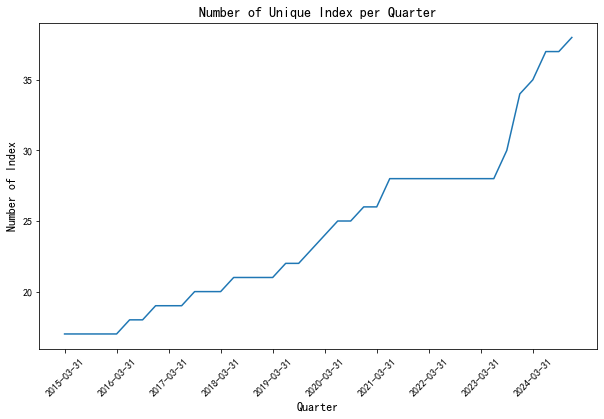

In [148]:
plt.figure(figsize=(10, 6))
plt.plot(unique_industries['Quarter'], unique_industries['四级分类'])
plt.title('Number of Unique Index per Quarter', fontsize=14)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Number of Index', fontsize=12)
plt.xticks(range(0, len(unique_industries['Quarter']), 4), 
           unique_industries['Quarter'][::4], rotation=45)
plt.show()

In [149]:
len(set(hangye['证券代码']))

228

In [150]:
hangye.loc[:, '市值亿元'] = hangye['UnitNVRestored'] * hangye['EndShares']/100000000

### 画Cash图

In [151]:
Shares=hangye[['证券代码','TradingDay','EndShares']].copy()
Shares

,证券代码,TradingDay,EndShares
0,159150.OF,2023-12-04,2.600998e+09
1,159150.OF,2023-12-11,2.600998e+09
2,159150.OF,2023-12-12,1.917998e+09
3,159150.OF,2023-12-13,1.419998e+09
4,159150.OF,2023-12-14,1.536998e+09
...,...,...,...
232638,588900.OF,2024-12-25,4.097830e+08
232639,588900.OF,2024-12-26,4.037830e+08
232640,588900.OF,2024-12-27,4.007830e+08
232641,588900.OF,2024-12-30,3.977830e+08


In [152]:
price=hangye[['证券代码','TradingDay','UnitNVRestored']].copy()
price

,证券代码,TradingDay,UnitNVRestored
0,159150.OF,2023-12-04,0.9996
1,159150.OF,2023-12-11,1.0046
2,159150.OF,2023-12-12,1.0037
3,159150.OF,2023-12-13,0.9859
4,159150.OF,2023-12-14,0.9796
...,...,...,...
232638,588900.OF,2024-12-25,0.9287
232639,588900.OF,2024-12-26,0.9441
232640,588900.OF,2024-12-27,0.9342
232641,588900.OF,2024-12-30,0.9270


In [153]:
# 考虑由于基金新成立而导致的资金流增加
Shares_pivot=Shares.pivot_table(index='TradingDay',columns='证券代码',values='EndShares',aggfunc='sum')
Shares_pivot.fillna(0,inplace=True)
fene=Shares_pivot.diff()
fene

证券代码,159150.OF,159300.OF,159330.OF,159337.OF,159350.OF,159351.OF,159352.OF,159353.OF,159505.OF,159517.OF,...,588380.OF,588390.OF,588400.OF,588450.OF,588460.OF,588500.OF,588680.OF,588800.OF,588880.OF,588900.OF
TradingDay,,,,,,,,,,,,,,,,,,,,,
2012-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-01-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-01-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-01-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-25,-2000000.0,10800000.0,0.0,0.0,3000000.0,216000000.0,378000000.0,21000000.0,0.0,0.0,...,-45000000.0,-3000000.0,-21000000.0,-3000000.0,-9000000.0,0.0,0.0,-17500000.0,-3000000.0,-3000000.0
2024-12-26,-4000000.0,10800000.0,-6000000.0,0.0,0.0,-99000000.0,-48000000.0,-111000000.0,0.0,0.0,...,-21000000.0,-6000000.0,-33000000.0,0.0,-15000000.0,-6000000.0,0.0,-100000000.0,-12000000.0,-6000000.0
2024-12-27,-3000000.0,5400000.0,0.0,0.0,-6000000.0,159000000.0,213000000.0,-18000000.0,0.0,0.0,...,36000000.0,0.0,-9000000.0,0.0,3000000.0,0.0,0.0,30000000.0,0.0,-3000000.0


In [154]:
price_pivot=price.pivot_table(index='TradingDay',columns='证券代码',values='UnitNVRestored',aggfunc='sum')
price_pivot

证券代码,159150.OF,159300.OF,159330.OF,159337.OF,159350.OF,159351.OF,159352.OF,159353.OF,159505.OF,159517.OF,...,588380.OF,588390.OF,588400.OF,588450.OF,588460.OF,588500.OF,588680.OF,588800.OF,588880.OF,588900.OF
TradingDay,,,,,,,,,,,,,,,,,,,,,
2012-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-25,1.2020,4.0770,1.1914,1.2864,1.1923,0.9903,1.0166,0.9851,1.0209,1.0912,...,0.5980,0.6385,0.5904,1.3199,1.1479,1.3084,1.3054,0.8968,0.8952,0.9287
2024-12-26,1.2071,4.0788,1.1920,1.2967,1.1974,0.9928,1.0192,0.9876,1.0330,1.0920,...,0.6030,0.6439,0.5953,1.3334,1.1651,1.3330,1.3278,0.9117,0.9099,0.9441
2024-12-27,1.2039,4.0724,1.1901,1.2993,1.1942,0.9915,1.0179,0.9863,1.0384,1.0913,...,0.5975,0.6380,0.5898,1.3206,1.1511,1.3171,1.3175,0.9021,0.9005,0.9342


In [155]:
cash=fene*price_pivot/100000000
cash.replace(0,np.nan,inplace=True)
cash

证券代码,159150.OF,159300.OF,159330.OF,159337.OF,159350.OF,159351.OF,159352.OF,159353.OF,159505.OF,159517.OF,...,588380.OF,588390.OF,588400.OF,588450.OF,588460.OF,588500.OF,588680.OF,588800.OF,588880.OF,588900.OF
TradingDay,,,,,,,,,,,,,,,,,,,,,
2012-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-25,-0.024040,0.440316,NaN,NaN,0.035769,2.139048,3.842748,0.206871,NaN,NaN,...,-0.269100,-0.019155,-0.123984,-0.039597,-0.103311,NaN,NaN,-0.156940,-0.026856,-0.027861
2024-12-26,-0.048284,0.440510,-0.071520,NaN,NaN,-0.982872,-0.489216,-1.096236,NaN,NaN,...,-0.126630,-0.038634,-0.196449,NaN,-0.174765,-0.079980,NaN,-0.911700,-0.109188,-0.056646
2024-12-27,-0.036117,0.219910,NaN,NaN,-0.071652,1.576485,2.168127,-0.177534,NaN,NaN,...,0.215100,NaN,-0.053082,NaN,0.034533,NaN,NaN,0.270630,NaN,-0.028026


In [156]:
def fill_nan_after_first_non_na(df):  
    def fill_column(col):
        first_non_na_index = col.first_valid_index()
        if first_non_na_index is not None:
            col.loc[col.index > first_non_na_index] = col.loc[col.index > first_non_na_index].fillna(0)  #对每一列第一次有值的行之后对于空值填写0
        return col
    return df.apply(fill_column, axis=0)

In [157]:
cash=fill_nan_after_first_non_na(cash)
cash

证券代码,159150.OF,159300.OF,159330.OF,159337.OF,159350.OF,159351.OF,159352.OF,159353.OF,159505.OF,159517.OF,...,588380.OF,588390.OF,588400.OF,588450.OF,588460.OF,588500.OF,588680.OF,588800.OF,588880.OF,588900.OF
TradingDay,,,,,,,,,,,,,,,,,,,,,
2012-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-25,-0.024040,0.440316,0.000000,0.000000,0.035769,2.139048,3.842748,0.206871,0.0,0.0,...,-0.269100,-0.019155,-0.123984,-0.039597,-0.103311,0.000000,0.0,-0.156940,-0.026856,-0.027861
2024-12-26,-0.048284,0.440510,-0.071520,0.000000,0.000000,-0.982872,-0.489216,-1.096236,0.0,0.0,...,-0.126630,-0.038634,-0.196449,0.000000,-0.174765,-0.079980,0.0,-0.911700,-0.109188,-0.056646
2024-12-27,-0.036117,0.219910,0.000000,0.000000,-0.071652,1.576485,2.168127,-0.177534,0.0,0.0,...,0.215100,0.000000,-0.053082,0.000000,0.034533,0.000000,0.0,0.270630,0.000000,-0.028026


In [158]:
cash=cash.stack().reset_index()
cash.rename(columns={0:'资金变化(亿元)'},inplace=True)

In [159]:
cashplot=cash.copy()
cashplot

,TradingDay,证券代码,资金变化(亿元)
0,2013-01-04,159901.OF,-2.258416
1,2013-01-04,159902.OF,-12.357158
2,2013-01-04,159903.OF,0.016729
3,2013-01-04,159912.OF,0.150163
4,2013-01-04,159915.OF,0.113088
...,...,...,...
233976,2024-12-31,588500.OF,0.025318
233977,2024-12-31,588680.OF,0.000000
233978,2024-12-31,588800.OF,0.303100
233979,2024-12-31,588880.OF,0.129660


In [160]:
cashplot['TradingDay'] = pd.to_datetime(cashplot['TradingDay'])
cashplot['Quarter'] = cashplot['TradingDay'].dt.to_period('Q')
cashplot['Quarter'] = cashplot['Quarter'].astype(str)
cashplot['Quarter'] =cashplot['Quarter'].apply(lambda x: x[:4] + quarter_to_date[x[4:]])
quarterly_cash= cashplot.groupby('Quarter')['资金变化(亿元)'].sum().reset_index()
quarterly_cash=quarterly_cash[quarterly_cash['Quarter'] >= '2015-03-31']
quarterly_cash

,Quarter,资金变化(亿元)
8,2015-03-31,-258.489794
9,2015-06-30,-567.662862
10,2015-09-30,351.534334
11,2015-12-31,-111.920281
12,2016-03-31,120.352281
13,2016-06-30,-28.388541
14,2016-09-30,-74.795990
15,2016-12-31,-7.604049
16,2017-03-31,-26.372738
17,2017-06-30,6.958260


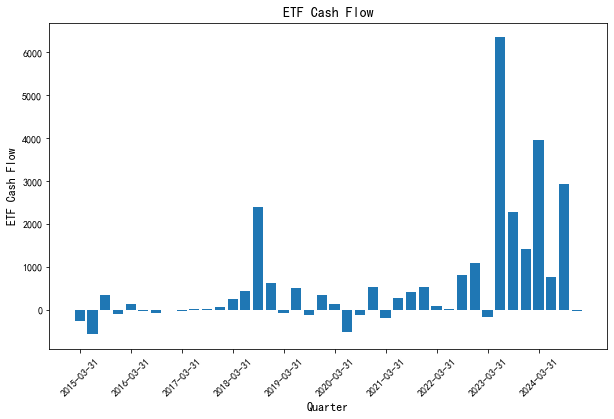

In [161]:
plt.figure(figsize=(10, 6))
plt.bar(quarterly_cash['Quarter'], quarterly_cash['资金变化(亿元)'])
plt.title('ETF Cash Flow', fontsize=14)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('ETF Cash Flow', fontsize=12)
plt.xticks(range(0, len(quarterly_cash['Quarter']), 4), 
           quarterly_cash['Quarter'][::4], rotation=45)
plt.show()

### 股权穿透

In [162]:
composite=pd.read_csv(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\组成.csv',index_col=0)
composite['SecuCode'] = composite['SecuCode'].apply(lambda x: x[:6] + x[6:])
composite.rename(columns={'SecuCode':'证券代码'},inplace=True)
composite['机构比例']=composite['InstitutionHoldShares']/(composite['IndividualHoldshares']+composite['InstitutionHoldShares'])
composite['个人比例']=composite['IndividualHoldshares']/(composite['IndividualHoldshares']+composite['InstitutionHoldShares'])

In [163]:
name1=pd.read_excel(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\宽基ETF名单.xlsx',sheet_name='宽基和联接')
name1['二级分类']=name1['跟踪指数代码']
name1['四级分类']=name1['二级分类']

name1

,跟踪指数代码,证券代码,证券简称,成立日期,按交易方式分类,一级分类,二级分类,四级分类
0,000016,510050.OF,华夏上证50ETF,2004-12-30,ETF,量化-普通被动指数型,000016,000016
1,000300,160706.OF,嘉实沪深300ETF联接(LOF)A,2005-08-29,ETF联接,量化-普通被动指数型,000300,000300
2,399330,159901.OF,易方达深证100ETF,2006-03-24,ETF,量化-普通被动指数型,399330,399330
3,000010,510180.OF,华安上证180ETF,2006-04-13,ETF,量化-普通被动指数型,000010,000010
4,399005,159902.OF,华夏中小企业100ETF,2006-06-08,ETF,量化-普通被动指数型,399005,399005
...,...,...,...,...,...,...,...,...
376,931643,588320.OF,广发中证科创创业50增强策略ETF,2022-12-28,ETF,量化-增强被动指数型,931643,931643
377,932000,159555.OF,银华中证2000增强策略ETF,2023-12-01,ETF,量化-增强被动指数型,932000,932000
378,932000,159556.OF,平安中证2000增强策略ETF,2023-12-27,ETF,量化-增强被动指数型,932000,932000
379,932000,159553.OF,海富通中证2000增强策略ETF,2024-03-27,ETF,量化-增强被动指数型,932000,932000


In [164]:
ETFlianjie=pd.read_csv(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\ETF链接.csv',index_col=0)
ETFlianjie

,SecuCode,InfoPublDate,EndDate,ETFFeederHoldShares,ETFFeederHoldRatio
0,000001.OF,2013-03-28,2012-12-31,NaN,NaN
1,000001.OF,2013-08-26,2013-06-30,NaN,NaN
2,000001.OF,2014-03-26,2013-12-31,NaN,NaN
3,000001.OF,2014-08-25,2014-06-30,NaN,NaN
4,000001.OF,2015-03-31,2014-12-31,NaN,NaN
...,...,...,...,...,...
224153,980003.OF,2021-03-29,2020-12-31,NaN,NaN
224154,980003.OF,2021-08-27,2021-06-30,NaN,NaN
224155,980003.OF,2022-03-31,2021-12-31,NaN,NaN
224156,980003.OF,2022-08-31,2022-06-30,NaN,NaN


In [165]:
ETFlianjie.rename(columns={'SecuCode':'证券代码'},inplace=True)
ETFlianjies=pd.merge(ETFlianjie,name1,on='证券代码',how='inner')
ETFlianjies.dropna(inplace=True)
ETFlianjies

,证券代码,InfoPublDate,EndDate,ETFFeederHoldShares,ETFFeederHoldRatio,跟踪指数代码,证券简称,成立日期,按交易方式分类,一级分类,二级分类,四级分类
1158,159150.OF,2024-08-30,2024-06-30,14606100.0,4.56,399850,易方达深证50ETF,2023-11-29,ETF,量化-普通被动指数型,399850,399850
1165,159350.OF,2024-08-31,2024-06-30,14653900.0,1.67,399850,富国深证50ETF,2023-11-30,ETF,量化-普通被动指数型,399850,399850
1200,159541.OF,2024-08-30,2024-06-30,73200000.0,38.41,399102,万家创业板综合ETF,2023-10-18,ETF,量化-普通被动指数型,399102,399102
1216,159563.OF,2024-08-30,2024-06-30,9749948.0,41.74,399102,华夏创业板综合ETF,2024-02-01,ETF,量化-普通被动指数型,399102,399102
1218,159571.OF,2024-08-31,2024-06-30,11414600.0,24.82,399019,富国创业板中盘200ETF,2023-12-20,ETF,量化-普通被动指数型,399019,399019
...,...,...,...,...,...,...,...,...,...,...,...,...
3520,588400.OF,2024-03-28,2023-12-31,352240000.0,9.74,931643,嘉实中证科创创业50ETF,2021-06-25,ETF,量化-普通被动指数型,931643,931643
3521,588400.OF,2024-08-30,2024-06-30,457198600.0,13.08,931643,嘉实中证科创创业50ETF,2021-06-25,ETF,量化-普通被动指数型,931643,931643
3533,588800.OF,2024-08-30,2024-06-30,481921100.0,10.35,000698,华夏上证科创板100ETF,2023-11-08,ETF,量化-普通被动指数型,000698,000698
3536,588880.OF,2024-08-31,2024-06-30,31288700.0,6.64,000698,华泰柏瑞上证科创板100ETF,2023-11-08,ETF,量化-普通被动指数型,000698,000698


In [166]:
len(ETFlianjies['证券代码'].unique())

146

In [167]:
ETFlianjies.sort_values(by='成立日期')

,证券代码,InfoPublDate,EndDate,ETFFeederHoldShares,ETFFeederHoldRatio,跟踪指数代码,证券简称,成立日期,按交易方式分类,一级分类,二级分类,四级分类
2314,510050.OF,2020-04-09,2019-12-31,572346315.0,3.79,000016,华夏上证50ETF,2004-12-30,ETF,量化-普通被动指数型,000016,000016
2308,510050.OF,2017-03-29,2016-12-31,318758964.0,2.49,000016,华夏上证50ETF,2004-12-30,ETF,量化-普通被动指数型,000016,000016
2309,510050.OF,2017-08-26,2017-06-30,323838964.0,2.77,000016,华夏上证50ETF,2004-12-30,ETF,量化-普通被动指数型,000016,000016
2310,510050.OF,2018-03-28,2017-12-31,246538931.0,1.85,000016,华夏上证50ETF,2004-12-30,ETF,量化-普通被动指数型,000016,000016
2311,510050.OF,2018-08-25,2018-06-30,286944631.0,2.11,000016,华夏上证50ETF,2004-12-30,ETF,量化-普通被动指数型,000016,000016
...,...,...,...,...,...,...,...,...,...,...,...,...
1238,159592.OF,2024-08-31,2024-06-30,532319673.0,13.37,930050,银华中证A50ETF,2024-03-06,ETF,量化-普通被动指数型,930050,930050
3365,563350.OF,2024-08-31,2024-06-30,81843100.0,4.05,930050,华泰柏瑞中证A50ETF,2024-03-06,ETF,量化-普通被动指数型,930050,930050
3341,562890.OF,2024-08-30,2024-06-30,183544400.0,25.26,930050,嘉实中证A50ETF,2024-03-07,ETF,量化-普通被动指数型,930050,930050
1247,159596.OF,2024-08-30,2024-06-30,214952300.0,10.60,930050,华宝中证A50ETF,2024-03-07,ETF,量化-普通被动指数型,930050,930050


In [168]:
composites=pd.merge(composite,name1,on=['证券代码'],how='inner')
composites.dropna(inplace=True)
composites

,证券代码,InfoPublDate,EndDate,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例,跟踪指数代码,证券简称,成立日期,按交易方式分类,一级分类,二级分类,四级分类
0,000008.OF,2013-08-26,2013-06-30,6.099832e+05,9.477354e+07,0.006395,0.993605,000905,嘉实中证500ETF联接A,2013-03-22,ETF联接,量化-普通被动指数型,000905,000905
1,000008.OF,2014-03-26,2013-12-31,6.099832e+05,6.194534e+07,0.009751,0.990249,000905,嘉实中证500ETF联接A,2013-03-22,ETF联接,量化-普通被动指数型,000905,000905
2,000008.OF,2014-08-25,2014-06-30,5.604603e+05,6.449902e+07,0.008615,0.991385,000905,嘉实中证500ETF联接A,2013-03-22,ETF联接,量化-普通被动指数型,000905,000905
3,000008.OF,2015-03-31,2014-12-31,1.874718e+06,1.800196e+08,0.010307,0.989693,000905,嘉实中证500ETF联接A,2013-03-22,ETF联接,量化-普通被动指数型,000905,000905
4,000008.OF,2015-08-29,2015-06-30,4.748373e+07,2.212901e+08,0.176668,0.823332,000905,嘉实中证500ETF联接A,2013-03-22,ETF联接,量化-普通被动指数型,000905,000905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3533,588800.OF,2024-08-30,2024-06-30,2.219161e+09,2.438216e+09,0.476483,0.523517,000698,华夏上证科创板100ETF,2023-11-08,ETF,量化-普通被动指数型,000698,000698
3535,588880.OF,2023-11-13,2023-11-09,1.304590e+08,9.289090e+08,0.123148,0.876852,000698,华泰柏瑞上证科创板100ETF,2023-11-08,ETF,量化-普通被动指数型,000698,000698
3536,588880.OF,2024-08-31,2024-06-30,1.091327e+08,3.622353e+08,0.231523,0.768477,000698,华泰柏瑞上证科创板100ETF,2023-11-08,ETF,量化-普通被动指数型,000698,000698
3538,588900.OF,2023-12-13,2023-12-11,1.289690e+08,7.608140e+08,0.144944,0.855056,000698,南方上证科创板100ETF,2023-12-08,ETF,量化-普通被动指数型,000698,000698


In [169]:
len(composites['证券代码'].unique())

358

In [170]:
columns_to_drop = ['跟踪指数代码','成立日期', '按交易方式分类', '一级分类', '二级分类']
composites= composites.drop(columns=columns_to_drop)
composites

,证券代码,InfoPublDate,EndDate,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例,证券简称,四级分类
0,000008.OF,2013-08-26,2013-06-30,6.099832e+05,9.477354e+07,0.006395,0.993605,嘉实中证500ETF联接A,000905
1,000008.OF,2014-03-26,2013-12-31,6.099832e+05,6.194534e+07,0.009751,0.990249,嘉实中证500ETF联接A,000905
2,000008.OF,2014-08-25,2014-06-30,5.604603e+05,6.449902e+07,0.008615,0.991385,嘉实中证500ETF联接A,000905
3,000008.OF,2015-03-31,2014-12-31,1.874718e+06,1.800196e+08,0.010307,0.989693,嘉实中证500ETF联接A,000905
4,000008.OF,2015-08-29,2015-06-30,4.748373e+07,2.212901e+08,0.176668,0.823332,嘉实中证500ETF联接A,000905
...,...,...,...,...,...,...,...,...,...
3533,588800.OF,2024-08-30,2024-06-30,2.219161e+09,2.438216e+09,0.476483,0.523517,华夏上证科创板100ETF,000698
3535,588880.OF,2023-11-13,2023-11-09,1.304590e+08,9.289090e+08,0.123148,0.876852,华泰柏瑞上证科创板100ETF,000698
3536,588880.OF,2024-08-31,2024-06-30,1.091327e+08,3.622353e+08,0.231523,0.768477,华泰柏瑞上证科创板100ETF,000698
3538,588900.OF,2023-12-13,2023-12-11,1.289690e+08,7.608140e+08,0.144944,0.855056,南方上证科创板100ETF,000698


In [171]:
datetime1=pd.read_csv(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\交易日.csv',index_col=0)
datetime1.rename(columns={'0': '日期'}, inplace=True)
datetime1.index=datetime1['日期']

In [172]:
def tradingday(date,datetime1):
    return datetime1.loc[:date,:].index[-1]

In [173]:
composites['InfoPublDate']=composites['InfoPublDate'].apply(lambda date: tradingday(date, datetime1))
composites.rename(columns={'InfoPublDate':'TradingDay'},inplace=True)
composites

,证券代码,TradingDay,EndDate,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例,证券简称,四级分类
0,000008.OF,2013-08-26,2013-06-30,6.099832e+05,9.477354e+07,0.006395,0.993605,嘉实中证500ETF联接A,000905
1,000008.OF,2014-03-26,2013-12-31,6.099832e+05,6.194534e+07,0.009751,0.990249,嘉实中证500ETF联接A,000905
2,000008.OF,2014-08-25,2014-06-30,5.604603e+05,6.449902e+07,0.008615,0.991385,嘉实中证500ETF联接A,000905
3,000008.OF,2015-03-31,2014-12-31,1.874718e+06,1.800196e+08,0.010307,0.989693,嘉实中证500ETF联接A,000905
4,000008.OF,2015-08-28,2015-06-30,4.748373e+07,2.212901e+08,0.176668,0.823332,嘉实中证500ETF联接A,000905
...,...,...,...,...,...,...,...,...,...
3533,588800.OF,2024-08-30,2024-06-30,2.219161e+09,2.438216e+09,0.476483,0.523517,华夏上证科创板100ETF,000698
3535,588880.OF,2023-11-13,2023-11-09,1.304590e+08,9.289090e+08,0.123148,0.876852,华泰柏瑞上证科创板100ETF,000698
3536,588880.OF,2024-08-30,2024-06-30,1.091327e+08,3.622353e+08,0.231523,0.768477,华泰柏瑞上证科创板100ETF,000698
3538,588900.OF,2023-12-13,2023-12-11,1.289690e+08,7.608140e+08,0.144944,0.855056,南方上证科创板100ETF,000698


In [174]:
lianjiegroup=composites[composites['证券简称'].str.contains('联接')].copy()
lianjiegroup.drop(columns=['TradingDay'],inplace=True)
lianjiegroup.rename(columns={'EndDate':'TradingDay'},inplace=True)
lianjiegroup

,证券代码,TradingDay,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例,证券简称,四级分类
0,000008.OF,2013-06-30,609983.25,9.477354e+07,0.006395,0.993605,嘉实中证500ETF联接A,000905
1,000008.OF,2013-12-31,609983.25,6.194534e+07,0.009751,0.990249,嘉实中证500ETF联接A,000905
2,000008.OF,2014-06-30,560460.29,6.449902e+07,0.008615,0.991385,嘉实中证500ETF联接A,000905
3,000008.OF,2014-12-31,1874717.81,1.800196e+08,0.010307,0.989693,嘉实中证500ETF联接A,000905
4,000008.OF,2015-06-30,47483726.63,2.212901e+08,0.176668,0.823332,嘉实中证500ETF联接A,000905
...,...,...,...,...,...,...,...,...
2271,470068.OF,2022-06-30,616.69,3.642599e+07,0.000017,0.999983,汇添富深证300ETF联接,399007
2272,470068.OF,2022-12-31,742250.79,3.773897e+07,0.019289,0.980711,汇添富深证300ETF联接,399007
2273,470068.OF,2023-06-30,647292.77,3.851734e+07,0.016527,0.983473,汇添富深证300ETF联接,399007
2274,470068.OF,2023-12-31,390136.16,3.951876e+07,0.009776,0.990224,汇添富深证300ETF联接,399007


In [175]:
merged1=pd.merge(ETF,name1,on='证券代码',how='inner')
merged1.sort_values(by=['证券代码','TradingDay'])
hangye1=merged1.copy()
hangye1['EndShares'] = hangye1.apply(lambda row: row['FloatShares'] if pd.isna(row['EndShares']) else row['EndShares'], axis=1)
hangye1 = hangye1.dropna(subset=['EndShares', 'FloatShares'], how='all')
hangye1.loc[:, '市值亿元'] = hangye1['UnitNVRestored'] * hangye1['EndShares']/100000000
market_value1=hangye1[['证券代码','TradingDay','四级分类','市值亿元']]
market_value1

,证券代码,TradingDay,四级分类,市值亿元
0,000008.OF,2013-06-30,000905,0.897845
1,000008.OF,2013-09-30,000905,0.688226
2,000008.OF,2013-12-31,000905,0.684605
3,000008.OF,2014-03-31,000905,0.646805
4,000008.OF,2014-06-30,000905,0.727170
...,...,...,...,...
247216,588900.OF,2024-12-25,000698,3.805655
247217,588900.OF,2024-12-26,000698,3.812115
247218,588900.OF,2024-12-27,000698,3.744115
247219,588900.OF,2024-12-30,000698,3.687448


In [176]:
lianjiegroupQ=pd.merge(lianjiegroup,market_value1,on=['证券代码','TradingDay','四级分类'])  #对于所有ETF联接，都是半年披露数据
lianjiegroupQ

,证券代码,TradingDay,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例,证券简称,四级分类,市值亿元
0,000008.OF,2013-06-30,609983.25,9.477354e+07,0.006395,0.993605,嘉实中证500ETF联接A,000905,0.897845
1,000008.OF,2013-12-31,609983.25,6.194534e+07,0.009751,0.990249,嘉实中证500ETF联接A,000905,0.684605
2,000008.OF,2014-06-30,560460.29,6.449902e+07,0.008615,0.991385,嘉实中证500ETF联接A,000905,0.727170
3,000008.OF,2014-12-31,1874717.81,1.800196e+08,0.010307,0.989693,嘉实中证500ETF联接A,000905,2.683305
4,000008.OF,2015-06-30,47483726.63,2.212901e+08,0.176668,0.823332,嘉实中证500ETF联接A,000905,6.403267
...,...,...,...,...,...,...,...,...,...
1210,470068.OF,2022-06-30,616.69,3.642599e+07,0.000017,0.999983,汇添富深证300ETF联接,399007,0.648467
1211,470068.OF,2022-12-31,742250.79,3.773897e+07,0.019289,0.980711,汇添富深证300ETF联接,399007,0.586723
1212,470068.OF,2023-06-30,647292.77,3.851734e+07,0.016527,0.983473,汇添富深证300ETF联接,399007,0.596399
1213,470068.OF,2023-12-31,390136.16,3.951876e+07,0.009776,0.990224,汇添富深证300ETF联接,399007,0.526398


In [177]:
def extract_prefix(name):
    return name.split('联接')[0]
lianjiegroupQ['前缀'] = lianjiegroupQ['证券简称'].apply(extract_prefix)
lianjiegroupQ

,证券代码,TradingDay,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例,证券简称,四级分类,市值亿元,前缀
0,000008.OF,2013-06-30,609983.25,9.477354e+07,0.006395,0.993605,嘉实中证500ETF联接A,000905,0.897845,嘉实中证500ETF
1,000008.OF,2013-12-31,609983.25,6.194534e+07,0.009751,0.990249,嘉实中证500ETF联接A,000905,0.684605,嘉实中证500ETF
2,000008.OF,2014-06-30,560460.29,6.449902e+07,0.008615,0.991385,嘉实中证500ETF联接A,000905,0.727170,嘉实中证500ETF
3,000008.OF,2014-12-31,1874717.81,1.800196e+08,0.010307,0.989693,嘉实中证500ETF联接A,000905,2.683305,嘉实中证500ETF
4,000008.OF,2015-06-30,47483726.63,2.212901e+08,0.176668,0.823332,嘉实中证500ETF联接A,000905,6.403267,嘉实中证500ETF
...,...,...,...,...,...,...,...,...,...,...
1210,470068.OF,2022-06-30,616.69,3.642599e+07,0.000017,0.999983,汇添富深证300ETF联接,399007,0.648467,汇添富深证300ETF
1211,470068.OF,2022-12-31,742250.79,3.773897e+07,0.019289,0.980711,汇添富深证300ETF联接,399007,0.586723,汇添富深证300ETF
1212,470068.OF,2023-06-30,647292.77,3.851734e+07,0.016527,0.983473,汇添富深证300ETF联接,399007,0.596399,汇添富深证300ETF
1213,470068.OF,2023-12-31,390136.16,3.951876e+07,0.009776,0.990224,汇添富深证300ETF联接,399007,0.526398,汇添富深证300ETF


In [178]:
lianjiegroupvalue=lianjiegroupQ.groupby(['前缀','TradingDay']).sum(numeric_only=True)['市值亿元'].reset_index()
lianjiegroupvalue

,前缀,TradingDay,市值亿元
0,万家创业板综合,2024-06-30,0.627575
1,万家国证2000,2022-12-31,0.083863
2,万家国证2000,2023-06-30,0.648652
3,万家国证2000,2023-12-31,0.961121
4,万家国证2000,2024-06-30,0.128373
...,...,...,...
1206,鹏扬中证科创创业50,2022-11-30,14.683138
1207,鹏扬中证科创创业50,2022-12-31,14.318307
1208,鹏扬中证科创创业50,2023-06-30,13.199743
1209,鹏扬中证科创创业50,2023-12-31,11.228621


In [179]:
lianjieweight=pd.merge(lianjiegroupQ,lianjiegroupvalue,on=['前缀','TradingDay'])
lianjieweight['权重']=lianjieweight['市值亿元_x']/lianjieweight['市值亿元_y']
lianjieweight.rename(columns={'TradingDay':'EndDate'},inplace=True)
lianjieweight

,证券代码,EndDate,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例,证券简称,四级分类,市值亿元_x,前缀,市值亿元_y,权重
0,000008.OF,2013-06-30,609983.25,9.477354e+07,0.006395,0.993605,嘉实中证500ETF联接A,000905,0.897845,嘉实中证500ETF,0.897845,1.0
1,000008.OF,2013-12-31,609983.25,6.194534e+07,0.009751,0.990249,嘉实中证500ETF联接A,000905,0.684605,嘉实中证500ETF,0.684605,1.0
2,000008.OF,2014-06-30,560460.29,6.449902e+07,0.008615,0.991385,嘉实中证500ETF联接A,000905,0.727170,嘉实中证500ETF,0.727170,1.0
3,000008.OF,2014-12-31,1874717.81,1.800196e+08,0.010307,0.989693,嘉实中证500ETF联接A,000905,2.683305,嘉实中证500ETF,2.683305,1.0
4,000008.OF,2015-06-30,47483726.63,2.212901e+08,0.176668,0.823332,嘉实中证500ETF联接A,000905,6.403267,嘉实中证500ETF,6.403267,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1210,470068.OF,2022-06-30,616.69,3.642599e+07,0.000017,0.999983,汇添富深证300ETF联接,399007,0.648467,汇添富深证300ETF,0.648467,1.0
1211,470068.OF,2022-12-31,742250.79,3.773897e+07,0.019289,0.980711,汇添富深证300ETF联接,399007,0.586723,汇添富深证300ETF,0.586723,1.0
1212,470068.OF,2023-06-30,647292.77,3.851734e+07,0.016527,0.983473,汇添富深证300ETF联接,399007,0.596399,汇添富深证300ETF,0.596399,1.0
1213,470068.OF,2023-12-31,390136.16,3.951876e+07,0.009776,0.990224,汇添富深证300ETF联接,399007,0.526398,汇添富深证300ETF,0.526398,1.0


In [180]:
weightforjigou=lianjieweight[['证券代码','EndDate','权重','前缀']]
weightforjigou

,证券代码,EndDate,权重,前缀
0,000008.OF,2013-06-30,1.0,嘉实中证500ETF
1,000008.OF,2013-12-31,1.0,嘉实中证500ETF
2,000008.OF,2014-06-30,1.0,嘉实中证500ETF
3,000008.OF,2014-12-31,1.0,嘉实中证500ETF
4,000008.OF,2015-06-30,1.0,嘉实中证500ETF
...,...,...,...,...
1210,470068.OF,2022-06-30,1.0,汇添富深证300ETF
1211,470068.OF,2022-12-31,1.0,汇添富深证300ETF
1212,470068.OF,2023-06-30,1.0,汇添富深证300ETF
1213,470068.OF,2023-12-31,1.0,汇添富深证300ETF


In [181]:
weightforjigou1=pd.merge(weightforjigou,composites[['证券代码','EndDate','机构比例']],on=['证券代码','EndDate'])
weightforjigou1['比例*权重']=weightforjigou1['权重']*weightforjigou1['机构比例']
biliquanzhong=weightforjigou1.groupby(['前缀','EndDate']).sum(numeric_only=True)['比例*权重'].reset_index()
biliquanzhonggeren=biliquanzhong.copy()
biliquanzhonggeren['比例*权重']=1-biliquanzhonggeren['比例*权重']
biliquanzhonggeren

,前缀,EndDate,比例*权重
0,万家创业板综合,2024-06-30,0.846823
1,万家国证2000,2022-12-31,0.413149
2,万家国证2000,2023-06-30,0.149327
3,万家国证2000,2023-12-31,0.133143
4,万家国证2000,2024-06-30,0.682136
...,...,...,...
1206,鹏扬中证科创创业50,2022-11-30,0.966140
1207,鹏扬中证科创创业50,2022-12-31,0.965987
1208,鹏扬中证科创创业50,2023-06-30,0.960192
1209,鹏扬中证科创创业50,2023-12-31,0.952146


In [182]:
ETFlianjiesratio=ETFlianjies.copy()
ETFlianjiesratio['ETFFeederHoldRatio']=ETFlianjiesratio['ETFFeederHoldRatio']/100
namehouxuan=list(ETFlianjiesratio['证券简称'].unique())
namehouxuan

['易方达深证50ETF',
 '富国深证50ETF',
 '万家创业板综合ETF',
 '华夏创业板综合ETF',
 '富国创业板中盘200ETF',
 '易方达创业板中盘200ETF',
 '华夏创业板中盘200ETF',
 '富国中证A50ETF',
 '银华中证A50ETF',
 '平安中证A50ETF',
 '大成中证A50ETF',
 '华宝中证A50ETF',
 '天弘中证科创创业50ETF',
 '景顺长城中证500增强策略ETF',
 '华夏中证100ETF',
 '万家国证2000ETF',
 '富国中证1000ETF',
 '易方达中证1000ETF',
 '鹏华沪深300ETF',
 '鹏华创业板50ETF',
 '景顺长城创业板50ETF',
 '易方达中证100ETF',
 '南方中证科创创业50ETF',
 '易方达中证科创创业50ETF',
 '华夏中证科创创业50ETF',
 '国寿安保国证创业板中盘精选88ETF',
 '浦银安盛创业板ETF',
 '西部利得创业板大盘ETF',
 '天弘中证500ETF',
 '中银证券创业板ETF',
 '天弘创业板300ETF',
 '华夏中证1000ETF',
 '易方达深证100ETF',
 '华夏中小企业100ETF',
 '南方深成ETF',
 '广发国证2000ETF',
 '博时创业板ETF',
 '汇添富深证300ETF',
 '易方达创业板ETF',
 '嘉实中创400ETF',
 '嘉实沪深300ETF',
 '嘉实中证500ETF',
 '南方沪深300ETF',
 '景顺长城中证500ETF',
 '南方创业板ETF',
 '华安创业板50ETF',
 '广发创业板ETF',
 '建信创业板ETF',
 '华夏创业板ETF',
 '工银瑞信创业板ETF',
 '方正富邦深证100ETF',
 '平安创业板ETF',
 '博时中证500ETF',
 '工银瑞信深证100ETF',
 '富国创业板ETF',
 '招商深证100ETF',
 '天弘创业板ETF',
 '鹏华中证500ETF',
 '招商创业板大盘ETF',
 '博时超大盘ETF',
 '华夏上证50ETF',
 '易方达上证50ETF',
 '易方达上证中盘ETF',
 '华安上证180ETF',
 '华安上

In [183]:
import difflib
def find_closest_name(prefix, namehouxuan):
    prefix_start = prefix[:2]
    candidates = [name for name in namehouxuan if prefix_start in name]
    if not candidates:
        return prefix
    matches = difflib.get_close_matches(prefix, candidates, n=1)
    return matches[0] if matches else prefix
def replace_prefix_with_closest(df, namehouxuan):
    df_copy = df.copy()  
    df_copy['前缀'] = df_copy['前缀'].apply(lambda x: find_closest_name(x, namehouxuan))
    return df_copy
biliquanzhonggerenrevise=replace_prefix_with_closest(biliquanzhonggeren,namehouxuan)
biliquanzhonggerenrevise

,前缀,EndDate,比例*权重
0,万家创业板综合ETF,2024-06-30,0.846823
1,万家国证2000ETF,2022-12-31,0.413149
2,万家国证2000ETF,2023-06-30,0.149327
3,万家国证2000ETF,2023-12-31,0.133143
4,万家国证2000ETF,2024-06-30,0.682136
...,...,...,...
1206,鹏扬中证科创创业50ETF,2022-11-30,0.966140
1207,鹏扬中证科创创业50ETF,2022-12-31,0.965987
1208,鹏扬中证科创创业50ETF,2023-06-30,0.960192
1209,鹏扬中证科创创业50ETF,2023-12-31,0.952146


In [184]:
biliquanzhonggerenrevise.rename(columns={'前缀':'证券简称'},inplace=True)
chuantoubili=pd.merge(ETFlianjiesratio,biliquanzhonggerenrevise,on=['EndDate','证券简称'],how='inner')
chuantoubili['穿透比例个人']=chuantoubili['ETFFeederHoldRatio']*chuantoubili['比例*权重']
chuantoubili[['证券代码','EndDate','穿透比例个人']]

,证券代码,EndDate,穿透比例个人
0,159150.OF,2024-06-30,0.007452
1,159350.OF,2024-06-30,0.003134
2,159541.OF,2024-06-30,0.325265
3,159571.OF,2024-06-30,0.008394
4,159573.OF,2024-06-30,0.002466
...,...,...,...
1120,588400.OF,2023-06-30,0.080716
1121,588400.OF,2023-12-31,0.090159
1122,588400.OF,2024-06-30,0.121753
1123,588800.OF,2024-06-30,0.021224


In [185]:
feilianjie=composites[~composites['证券简称'].str.contains('联接')]
feilianjie1=pd.merge(feilianjie,chuantoubili[['证券代码','EndDate','穿透比例个人']],on=['证券代码','EndDate'],how='left').fillna(0)
feilianjie1['机构比例']=feilianjie1['机构比例']-feilianjie1['穿透比例个人']
feilianjie1['个人比例']=1-feilianjie1['机构比例']
feilianjie1.drop(columns=['穿透比例个人'],inplace=True)
feilianjie1

,证券代码,TradingDay,EndDate,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例,证券简称,四级分类
0,159150.OF,2023-12-06,2023-12-04,1.511041e+08,2.449894e+09,0.058095,0.941905,易方达深证50ETF,399850
1,159150.OF,2024-08-30,2024-06-30,1.680683e+08,1.519294e+08,0.517766,0.482234,易方达深证50ETF,399850
2,159300.OF,2024-05-31,2024-05-29,7.466942e+07,6.419276e+08,0.104200,0.895800,富国沪深300ETF,000300
3,159330.OF,2024-08-14,2024-08-12,1.563837e+08,9.241735e+07,0.628549,0.371451,东财沪深300ETF,000300
4,159337.OF,2024-09-13,2024-09-11,2.030632e+08,8.647363e+06,0.959155,0.040845,东财中证500ETF,000905
...,...,...,...,...,...,...,...,...,...
1960,588800.OF,2024-08-30,2024-06-30,2.219161e+09,2.438216e+09,0.455259,0.544741,华夏上证科创板100ETF,000698
1961,588880.OF,2023-11-13,2023-11-09,1.304590e+08,9.289090e+08,0.123148,0.876852,华泰柏瑞上证科创板100ETF,000698
1962,588880.OF,2024-08-30,2024-06-30,1.091327e+08,3.622353e+08,0.200106,0.799894,华泰柏瑞上证科创板100ETF,000698
1963,588900.OF,2023-12-13,2023-12-11,1.289690e+08,7.608140e+08,0.144944,0.855056,南方上证科创板100ETF,000698


In [186]:
feilianjie1=pd.merge(feilianjie1,hangye1[['证券代码','EndDate','证券简称','成立日期','市值亿元']],on=['证券代码','证券简称','EndDate'])
feilianjie1

,证券代码,TradingDay,EndDate,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例,证券简称,四级分类,成立日期,市值亿元
0,159150.OF,2023-12-06,2023-12-04,1.511041e+08,2.449894e+09,0.058095,0.941905,易方达深证50ETF,399850,2023-11-29,25.999572
1,159150.OF,2024-08-30,2024-06-30,1.680683e+08,1.519294e+08,0.517766,0.482234,易方达深证50ETF,399850,2023-11-29,3.212456
2,159300.OF,2024-05-31,2024-05-29,7.466942e+07,6.419276e+08,0.104200,0.895800,富国沪深300ETF,000300,2024-05-23,7.166687
3,159330.OF,2024-08-14,2024-08-12,1.563837e+08,9.241735e+07,0.628549,0.371451,东财沪深300ETF,000300,2024-08-01,2.487512
4,159337.OF,2024-09-13,2024-09-11,2.030632e+08,8.647363e+06,0.959155,0.040845,东财中证500ETF,000905,2024-09-02,2.117318
...,...,...,...,...,...,...,...,...,...,...,...
1960,588800.OF,2024-08-30,2024-06-30,2.219161e+09,2.438216e+09,0.455259,0.544741,华夏上证科创板100ETF,000698,2023-11-08,32.801906
1961,588880.OF,2023-11-13,2023-11-09,1.304590e+08,9.289090e+08,0.123148,0.876852,华泰柏瑞上证科创板100ETF,000698,2023-11-08,10.592621
1962,588880.OF,2024-08-30,2024-06-30,1.091327e+08,3.622353e+08,0.200106,0.799894,华泰柏瑞上证科创板100ETF,000698,2023-11-08,3.311360
1963,588900.OF,2023-12-13,2023-12-11,1.289690e+08,7.608140e+08,0.144944,0.855056,南方上证科创板100ETF,000698,2023-12-08,8.899610


In [187]:
print(feilianjie1['EndDate'].min())
print(feilianjie1['EndDate'].max())

2012-12-31
2024-10-08


In [188]:
dateH = pd.date_range(start='2015-06-30', end='2024-12-31', freq='6M')
dateH = dateH[(dateH.month == 6) | (dateH.month == 12)]
dateH=[date.strftime('%Y-%m-%d')for date in dateH]
dateH

['2015-06-30',
 '2015-12-31',
 '2016-06-30',
 '2016-12-31',
 '2017-06-30',
 '2017-12-31',
 '2018-06-30',
 '2018-12-31',
 '2019-06-30',
 '2019-12-31',
 '2020-06-30',
 '2020-12-31',
 '2021-06-30',
 '2021-12-31',
 '2022-06-30',
 '2022-12-31',
 '2023-06-30',
 '2023-12-31',
 '2024-06-30',
 '2024-12-31']

In [189]:
hangyeguquandigao=feilianjie1[feilianjie1['EndDate'].isin(dateH)]
hangyeguquandigao['EndDate'].min()

'2015-06-30'

In [190]:
hangyeguquandigao=hangyeguquandigao.sort_values(by='成立日期').copy()
hangyeguquandigao

,证券代码,TradingDay,EndDate,InstitutionHoldShares,IndividualHoldshares,机构比例,个人比例,证券简称,四级分类,成立日期,市值亿元
812,510050.OF,2016-03-29,2015-12-31,9.927669e+09,2.537098e+09,0.781670,0.218330,华夏上证50ETF,000016,2004-12-30,301.522708
811,510050.OF,2015-08-28,2015-06-30,1.027825e+10,3.489718e+09,0.735343,0.264657,华夏上证50ETF,000016,2004-12-30,391.974014
813,510050.OF,2016-08-26,2016-06-30,9.981236e+09,2.572631e+09,0.779777,0.220223,华夏上证50ETF,000016,2004-12-30,268.527210
814,510050.OF,2017-03-29,2016-12-31,1.032978e+10,2.468885e+09,0.792490,0.207510,华夏上证50ETF,000016,2004-12-30,293.089469
815,510050.OF,2017-08-25,2017-06-30,9.689908e+09,2.011658e+09,0.812265,0.187735,华夏上证50ETF,000016,2004-12-30,299.911156
...,...,...,...,...,...,...,...,...,...,...,...
1791,562890.OF,2024-08-30,2024-06-30,5.068207e+08,2.197303e+08,0.459655,0.540345,嘉实中证A50ETF,930050,2024-03-07,7.131825
66,159596.OF,2024-08-30,2024-06-30,1.839157e+09,1.886845e+08,0.849171,0.150829,华宝中证A50ETF,930050,2024-03-07,19.694397
38,159553.OF,2024-08-30,2024-06-30,7.506330e+05,1.157612e+07,0.060895,0.939105,海富通中证2000增强策略ETF,932000,2024-03-27,0.113369
1804,563280.OF,2024-08-30,2024-06-30,3.091100e+06,1.111551e+07,0.217582,0.782418,富国MSCI中国A50互联互通增强策略ETF,746059,2024-04-01,0.143487


In [191]:
pivot_tablehangyejigoubili=hangyeguquandigao.pivot_table(index=['证券代码', '证券简称', '成立日期'], 
                             columns='EndDate', 
                             values='机构比例').sort_index(level=['成立日期'])
pivot_tablehangyejigoubili

,,EndDate,2015-06-30,2015-12-31,2016-06-30,2016-12-31,2017-06-30,2017-12-31,2018-06-30,2018-12-31,2019-06-30,2019-12-31,2020-06-30,2020-12-31,2021-06-30,2021-12-31,2022-06-30,2022-12-31,2023-06-30,2023-12-31,2024-06-30
证券代码,证券简称,成立日期,,,,,,,,,,,,,,,,,,,
510050.OF,华夏上证50ETF,2004-12-30,0.735343,0.781670,0.779777,0.792490,0.812265,0.801703,0.726698,0.661178,0.702467,0.712245,0.699457,0.775319,0.717784,0.736632,0.675257,0.669015,0.659421,0.682894,0.803060
159901.OF,易方达深证100ETF,2006-03-24,0.325756,0.491299,0.393085,0.316144,0.310181,0.281487,0.321384,0.344499,0.544787,0.594475,0.620557,0.611662,0.605299,0.591768,0.577478,0.554045,0.559833,0.507404,0.505511
510180.OF,华安上证180ETF,2006-04-13,0.805232,0.939889,0.941371,0.946231,0.955910,0.959862,0.953581,0.941139,0.953652,0.955474,0.959077,0.966656,0.967198,0.967962,0.966183,0.963322,0.960855,0.956763,0.959575
159902.OF,华夏中小企业100ETF,2006-06-08,0.298866,0.551566,0.560896,0.534030,0.553559,0.546832,0.528179,0.461099,0.512655,0.527473,0.574174,0.204245,0.152236,0.056202,0.097531,0.050178,0.068494,0.047498,0.060004
159903.OF,南方深成ETF,2009-12-04,0.136033,0.050354,0.048925,0.035110,0.036717,0.012490,0.039797,0.036908,0.004542,0.010123,0.007374,0.011940,0.028857,0.010499,0.009893,0.050477,0.071647,0.058153,0.057534
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159596.OF,华宝中证A50ETF,2024-03-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.849171
562890.OF,嘉实中证A50ETF,2024-03-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.459655
159553.OF,海富通中证2000增强策略ETF,2024-03-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.060895


In [192]:
pivot_tablehangyevalue=hangyeguquandigao.pivot_table(index=['证券代码', '证券简称', '成立日期'], 
                             columns='EndDate', 
                             values='市值亿元').sort_index(level=['成立日期'])
pivot_tablehangyevalue

,,EndDate,2015-06-30,2015-12-31,2016-06-30,2016-12-31,2017-06-30,2017-12-31,2018-06-30,2018-12-31,2019-06-30,2019-12-31,2020-06-30,2020-12-31,2021-06-30,2021-12-31,2022-06-30,2022-12-31,2023-06-30,2023-12-31,2024-06-30
证券代码,证券简称,成立日期,,,,,,,,,,,,,,,,,,,
510050.OF,华夏上证50ETF,2004-12-30,391.974014,301.522708,268.527210,293.089469,299.911156,380.837863,340.622864,457.872487,492.628369,461.908627,395.117817,565.764732,544.388223,691.454834,531.173174,582.966459,576.226096,802.993278,1130.059108
159901.OF,易方达深证100ETF,2006-03-24,67.325268,58.899696,42.515446,35.224421,36.958426,40.487310,33.681956,33.576631,67.143601,80.548422,82.994040,98.224801,97.667808,81.025417,71.606933,64.223900,66.937338,63.803146,59.844024
510180.OF,华安上证180ETF,2006-04-13,91.829061,192.255920,161.907873,171.334097,188.584198,200.704191,173.170716,159.249938,198.224813,199.559306,194.039626,239.046656,235.431604,228.871310,215.247724,192.980003,193.595458,188.816050,191.855091
159902.OF,华夏中小企业100ETF,2006-06-08,25.426991,29.445823,28.627085,24.177065,24.510070,26.287697,23.545970,19.815857,23.098637,23.654041,26.016934,14.883707,12.071032,9.539710,8.601397,6.986887,7.197762,6.374374,6.071691
159903.OF,南方深成ETF,2009-12-04,9.369633,6.261805,5.410911,4.960584,4.921502,4.541134,4.016829,3.491694,4.067426,4.019467,4.089148,3.756988,3.468674,2.973625,2.686214,2.453754,2.745853,3.353642,3.714174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159596.OF,华宝中证A50ETF,2024-03-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.694397
562890.OF,嘉实中证A50ETF,2024-03-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.131825
159553.OF,海富通中证2000增强策略ETF,2024-03-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.113369


In [193]:
pivot_tablehangyegeren=hangyeguquandigao.pivot_table(index=['证券代码', '证券简称', '成立日期'], 
                             columns='EndDate', 
                             values='个人比例').sort_index(level=['成立日期'])
pivot_tablehangyegeren

,,EndDate,2015-06-30,2015-12-31,2016-06-30,2016-12-31,2017-06-30,2017-12-31,2018-06-30,2018-12-31,2019-06-30,2019-12-31,2020-06-30,2020-12-31,2021-06-30,2021-12-31,2022-06-30,2022-12-31,2023-06-30,2023-12-31,2024-06-30
证券代码,证券简称,成立日期,,,,,,,,,,,,,,,,,,,
510050.OF,华夏上证50ETF,2004-12-30,0.264657,0.218330,0.220223,0.207510,0.187735,0.198297,0.273302,0.338822,0.297533,0.287755,0.300543,0.224681,0.282216,0.263368,0.324743,0.330985,0.340579,0.317106,0.196940
159901.OF,易方达深证100ETF,2006-03-24,0.674244,0.508701,0.606915,0.683856,0.689819,0.718513,0.678616,0.655501,0.455213,0.405525,0.379443,0.388338,0.394701,0.408232,0.422522,0.445955,0.440167,0.492596,0.494489
510180.OF,华安上证180ETF,2006-04-13,0.194768,0.060111,0.058629,0.053769,0.044090,0.040138,0.046419,0.058861,0.046348,0.044526,0.040923,0.033344,0.032802,0.032038,0.033817,0.036678,0.039145,0.043237,0.040425
159902.OF,华夏中小企业100ETF,2006-06-08,0.701134,0.448434,0.439104,0.465970,0.446441,0.453168,0.471821,0.538901,0.487345,0.472527,0.425826,0.795755,0.847764,0.943798,0.902469,0.949822,0.931506,0.952502,0.939996
159903.OF,南方深成ETF,2009-12-04,0.863967,0.949646,0.951075,0.964890,0.963283,0.987510,0.960203,0.963092,0.995458,0.989877,0.992626,0.988060,0.971143,0.989501,0.990107,0.949523,0.928353,0.941847,0.942466
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159596.OF,华宝中证A50ETF,2024-03-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.150829
562890.OF,嘉实中证A50ETF,2024-03-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.540345
159553.OF,海富通中证2000增强策略ETF,2024-03-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.939105


In [194]:
guimoforjigou=pivot_tablehangyejigoubili*pivot_tablehangyevalue
guimoforjigou

,,EndDate,2015-06-30,2015-12-31,2016-06-30,2016-12-31,2017-06-30,2017-12-31,2018-06-30,2018-12-31,2019-06-30,2019-12-31,2020-06-30,2020-12-31,2021-06-30,2021-12-31,2022-06-30,2022-12-31,2023-06-30,2023-12-31,2024-06-30
证券代码,证券简称,成立日期,,,,,,,,,,,,,,,,,,,
510050.OF,华夏上证50ETF,2004-12-30,288.235437,235.691302,209.391344,232.270417,243.607396,305.318704,247.530074,302.735425,346.055271,328.992190,276.367906,438.648187,390.752890,509.347740,358.678156,390.013478,379.975531,548.358931,907.505532
159901.OF,易方达深证100ETF,2006-03-24,21.931608,28.937382,16.712194,11.135992,11.463784,11.396631,10.824851,11.567125,36.578980,47.883985,51.502529,60.080349,59.118224,47.948209,41.351424,35.582926,37.473721,32.373949,30.251789
510180.OF,华安上证180ETF,2006-04-13,73.943675,180.699188,152.415420,162.121596,180.269546,192.648359,165.132233,149.876397,189.037528,190.673749,186.098947,231.075938,227.708886,221.538638,207.968725,185.901843,186.017150,180.652287,184.099271
159902.OF,华夏中小企业100ETF,2006-06-08,7.599274,16.241315,16.056822,12.911288,13.567764,14.374961,12.436495,9.137067,11.841623,12.476861,14.938255,3.039927,1.837643,0.536154,0.838907,0.350586,0.493003,0.302768,0.364329
159903.OF,南方深成ETF,2009-12-04,1.274578,0.315308,0.264730,0.174167,0.180702,0.056719,0.159857,0.128873,0.018473,0.040691,0.030152,0.044860,0.100095,0.031220,0.026576,0.123859,0.196733,0.195024,0.213691
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159596.OF,华宝中证A50ETF,2024-03-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.723910
562890.OF,嘉实中证A50ETF,2024-03-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.278180
159553.OF,海富通中证2000增强策略ETF,2024-03-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006904


In [195]:
guimoforgeren=pivot_tablehangyegeren*pivot_tablehangyevalue
guimoforgeren

,,EndDate,2015-06-30,2015-12-31,2016-06-30,2016-12-31,2017-06-30,2017-12-31,2018-06-30,2018-12-31,2019-06-30,2019-12-31,2020-06-30,2020-12-31,2021-06-30,2021-12-31,2022-06-30,2022-12-31,2023-06-30,2023-12-31,2024-06-30
证券代码,证券简称,成立日期,,,,,,,,,,,,,,,,,,,
510050.OF,华夏上证50ETF,2004-12-30,103.738577,65.831406,59.135866,60.819052,56.303760,75.519159,93.092790,155.137062,146.573099,132.916437,118.749910,127.116545,153.635333,182.107094,172.495019,192.952981,196.250565,254.634348,222.553576
159901.OF,易方达深证100ETF,2006-03-24,45.393660,29.962314,25.803252,24.088429,25.494642,29.090679,22.857104,22.009506,30.564622,32.664437,31.491511,38.144452,38.549584,33.077208,30.255509,28.640974,29.463617,31.429197,29.592235
510180.OF,华安上证180ETF,2006-04-13,17.885385,11.556732,9.492453,9.212501,8.314652,8.055832,8.038482,9.373541,9.187285,8.885558,7.940679,7.970718,7.722718,7.332672,7.278999,7.078160,7.578309,8.163762,7.755820
159902.OF,华夏中小企业100ETF,2006-06-08,17.827717,13.204508,12.570263,11.265777,10.942305,11.912736,11.109475,10.678790,11.257014,11.177180,11.078679,11.843780,10.233389,9.003555,7.762490,6.636300,6.704758,6.071606,5.707362
159903.OF,南方深成ETF,2009-12-04,8.095055,5.946498,5.146181,4.786417,4.740799,4.484414,3.856972,3.362822,4.048953,3.978776,4.058996,3.712128,3.368579,2.942405,2.659638,2.329895,2.549120,3.158618,3.500483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159596.OF,华宝中证A50ETF,2024-03-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.970487
562890.OF,嘉实中证A50ETF,2024-03-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.853645
159553.OF,海富通中证2000增强策略ETF,2024-03-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.106466


In [196]:
jigougerenguimo=pd.concat([guimoforjigou.sum(), guimoforgeren.sum()], axis=1)
jigougerenguimo.columns=['机构规模', '个人规模']
jigougerenguimo['机构比例']=jigougerenguimo['机构规模']/(jigougerenguimo['机构规模']+jigougerenguimo['个人规模'])*100
jigougerenguimo['个人比例']=jigougerenguimo['个人规模']/(jigougerenguimo['机构规模']+jigougerenguimo['个人规模'])*100
jigougerenguimo['规模和']=jigougerenguimo['机构规模']+jigougerenguimo['个人规模']
jigougerenguimo

,机构规模,个人规模,机构比例,个人比例,规模和
EndDate,,,,,
2015-06-30,881.372303,652.002016,57.479266,42.520734,1533.374319
2015-12-31,1078.024584,498.154553,68.394801,31.605199,1576.179137
2016-06-30,954.631700,466.770667,67.161257,32.838743,1421.402367
2016-12-31,911.225760,484.709937,65.277058,34.722942,1395.935697
2017-06-30,985.119246,503.946230,66.156879,33.843121,1489.065475
2017-12-31,1059.984488,547.433426,65.943304,34.056696,1607.417914
2018-06-30,1136.898455,695.515287,62.043764,37.956236,1832.413742
2018-12-31,1421.390315,947.675584,59.997922,40.002078,2369.065899
2019-06-30,1961.947180,1137.399482,63.301960,36.698040,3099.346663


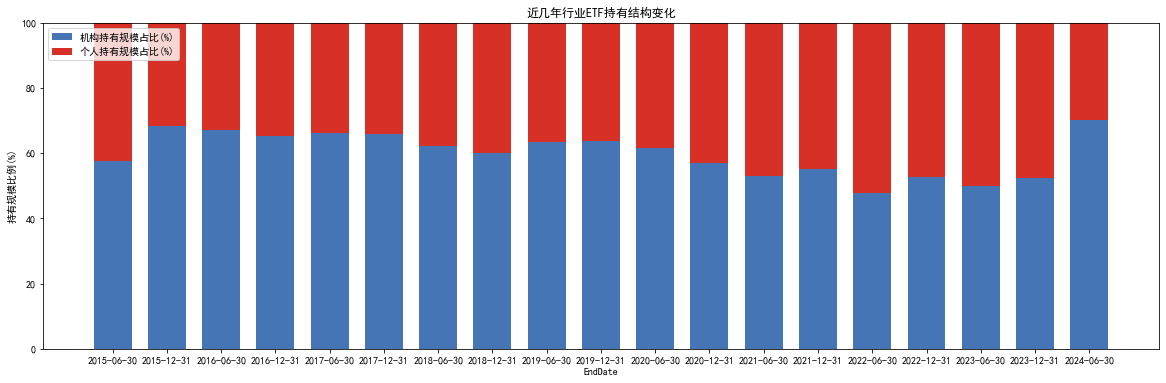

In [197]:
plt.figure(figsize=(20, 6))#如果数据团在这里，改这里就行哈

plt.bar(jigougerenguimo.index, jigougerenguimo['机构比例'], color='#4575b4', label='机构持有规模占比(%)', width=0.7)
plt.bar(jigougerenguimo.index, jigougerenguimo['个人比例'], bottom=jigougerenguimo['机构比例'], color='#d73027', label='个人持有规模占比(%)', width=0.7)
plt.xlabel('EndDate')
plt.ylabel('持有规模比例(%)')
plt.title('近几年行业ETF持有结构变化')

plt.legend(loc='upper left')
plt.ylim(0, 100)
plt.savefig('近几年行业ETF持有结构变化.png', dpi=300)

In [198]:
excel_writer=pd.ExcelWriter(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\底稿.xlsx', engine='openpyxl', mode='a')
unique_industries.to_excel(excel_writer,sheet_name='宽基覆盖个数',index=False)
quarterly_cash.to_excel(excel_writer, sheet_name='宽基资金净申赎', index=False)
pivot_tablehangyejigoubili.to_excel(excel_writer, sheet_name='宽基机构穿透比例')
pivot_tablehangyevalue.to_excel(excel_writer, sheet_name='宽基ETF规模时序')
jigougerenguimo.to_excel(excel_writer, sheet_name='宽基机构与个人总规模时序变化')

In [199]:
excel_writer.save()
excel_writer.close()

### 前10大拆分

In [200]:
Top=pd.read_csv(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\Top10.csv',index_col=0)
Top.drop_duplicates(subset=['SecuCode','InfoPublDate','SerialNumber','HolderName'],keep='last',inplace=True)
Top.rename(columns={'SecuCode':'证券代码'},inplace=True)
Top   #Topvalue是所有可以拿到数据的ETF前10大

,证券代码,InfoPublDate,EndDate,SerialNumber,HolderName,HoldingVolume,HoldingRatio
0,000009.OF,2018-03-30,2017-12-31,4,银行类机构,1.226588e+09,0.017849
1,000009.OF,2018-03-30,2017-12-31,5,银行类机构,1.022156e+09,0.014874
2,000009.OF,2018-03-30,2017-12-31,6,银行类机构,1.014304e+09,0.014760
3,000009.OF,2018-03-30,2017-12-31,7,信托类机构,7.517495e+08,0.010939
4,000009.OF,2018-03-30,2017-12-31,8,银行类机构,7.160422e+08,0.010420
...,...,...,...,...,...,...,...
263761,970196.OF,2024-07-31,2024-06-30,2,个人,4.715367e+06,0.020800
263762,970196.OF,2024-07-31,2024-06-30,3,个人,4.241674e+06,0.018700
263763,970196.OF,2024-07-31,2024-06-30,4,个人,3.946527e+06,0.017400
263764,970196.OF,2024-07-31,2024-06-30,5,个人,3.746199e+06,0.016500


In [201]:
Tops=pd.merge(Top,name1,on='证券代码',how='inner')
Tops['InfoPublDate']=Tops['InfoPublDate'].apply(lambda date: tradingday(date, datetime1))
Tops=Tops[~Tops['证券简称'].str.contains('联接')]

In [202]:
filtered_topdates=Tops['EndDate'].sort_values().unique()
filtered_topdates=[date for date in filtered_topdates if date.endswith('06-30') or date.endswith('12-31')]
filtered_topdates

['2012-12-31',
 '2013-06-30',
 '2013-12-31',
 '2014-06-30',
 '2014-12-31',
 '2015-06-30',
 '2015-12-31',
 '2016-06-30',
 '2016-12-31',
 '2017-06-30',
 '2017-12-31',
 '2018-06-30',
 '2018-12-31',
 '2019-06-30',
 '2019-12-31',
 '2020-06-30',
 '2020-12-31',
 '2021-06-30',
 '2021-12-31',
 '2022-06-30',
 '2022-12-31',
 '2023-06-30',
 '2023-12-31',
 '2024-06-30']

In [203]:
filterdtops=Tops[Tops['EndDate'].isin(filtered_topdates)].reset_index(drop=True)
filterdtops.rename(columns={'EndDate':'TradingDay'},inplace=True)
filterdtops  #TradingDay只保留半年度date

,证券代码,InfoPublDate,TradingDay,SerialNumber,HolderName,HoldingVolume,HoldingRatio,跟踪指数代码,证券简称,成立日期,按交易方式分类,一级分类,二级分类,四级分类
0,159150.OF,2024-08-30,2024-06-30,1,中国人寿保险股份有限公司,99999883.0,0.3125,399850,易方达深证50ETF,2023-11-29,ETF,量化-普通被动指数型,399850,399850
1,159150.OF,2024-08-30,2024-06-30,10,徐华,3000000.0,0.0094,399850,易方达深证50ETF,2023-11-29,ETF,量化-普通被动指数型,399850,399850
2,159150.OF,2024-08-30,2024-06-30,6,广发证券股份有限公司,4659894.0,0.0146,399850,易方达深证50ETF,2023-11-29,ETF,量化-普通被动指数型,399850,399850
3,159150.OF,2024-08-30,2024-06-30,2,海通证券股份有限公司,7730747.0,0.0242,399850,易方达深证50ETF,2023-11-29,ETF,量化-普通被动指数型,399850,399850
4,159150.OF,2024-08-30,2024-06-30,3,中信证券股份有限公司,5587520.0,0.0175,399850,易方达深证50ETF,2023-11-29,ETF,量化-普通被动指数型,399850,399850
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18671,588900.OF,2024-08-30,2024-06-30,5,铭珈资本管理(深圳)有限公司-铭珈未来5号私募证券投资基金,5010000.0,0.0144,000698,南方上证科创板100ETF,2023-12-08,ETF,量化-普通被动指数型,000698,000698
18672,588900.OF,2024-08-30,2024-06-30,10,张燕茹,3000000.0,0.0087,000698,南方上证科创板100ETF,2023-12-08,ETF,量化-普通被动指数型,000698,000698
18673,588900.OF,2024-08-30,2024-06-30,2,方正证券股份有限公司,12149000.0,0.0350,000698,南方上证科创板100ETF,2023-12-08,ETF,量化-普通被动指数型,000698,000698
18674,588900.OF,2024-08-30,2024-06-30,1,申万宏源证券有限公司,24583900.0,0.0709,000698,南方上证科创板100ETF,2023-12-08,ETF,量化-普通被动指数型,000698,000698


In [204]:
Topvalue=pd.merge(market_value1,filterdtops[['证券代码','InfoPublDate','TradingDay','HoldingVolume','HolderName','HoldingRatio','四级分类']],on=['证券代码','TradingDay','四级分类'])
Topvalue['购买市值亿元']=Topvalue['市值亿元']*Topvalue['HoldingRatio']
Topvalue['TradingDay']=pd.to_datetime(Topvalue['TradingDay'])
Topvalue

,证券代码,TradingDay,四级分类,市值亿元,InfoPublDate,HoldingVolume,HolderName,HoldingRatio,购买市值亿元
0,159150.OF,2024-06-30,399850,3.212456,2024-08-30,99999883.0,中国人寿保险股份有限公司,0.3125,1.003893
1,159150.OF,2024-06-30,399850,3.212456,2024-08-30,3000000.0,徐华,0.0094,0.030197
2,159150.OF,2024-06-30,399850,3.212456,2024-08-30,4659894.0,广发证券股份有限公司,0.0146,0.046902
3,159150.OF,2024-06-30,399850,3.212456,2024-08-30,7730747.0,海通证券股份有限公司,0.0242,0.077741
4,159150.OF,2024-06-30,399850,3.212456,2024-08-30,5587520.0,中信证券股份有限公司,0.0175,0.056218
...,...,...,...,...,...,...,...,...,...
18671,588900.OF,2024-06-30,000698,2.531516,2024-08-30,5010000.0,铭珈资本管理(深圳)有限公司-铭珈未来5号私募证券投资基金,0.0144,0.036454
18672,588900.OF,2024-06-30,000698,2.531516,2024-08-30,3000000.0,张燕茹,0.0087,0.022024
18673,588900.OF,2024-06-30,000698,2.531516,2024-08-30,12149000.0,方正证券股份有限公司,0.0350,0.088603
18674,588900.OF,2024-06-30,000698,2.531516,2024-08-30,24583900.0,申万宏源证券有限公司,0.0709,0.179484


In [205]:
Top_holder = Topvalue[~Topvalue['HolderName'].str.contains('联接|基金发起')].copy() 
Top_holder.drop_duplicates(subset=['证券代码','TradingDay','四级分类','InfoPublDate','HolderName'],keep='last',inplace=True) 

In [206]:
Top_holder

,证券代码,TradingDay,四级分类,市值亿元,InfoPublDate,HoldingVolume,HolderName,HoldingRatio,购买市值亿元
0,159150.OF,2024-06-30,399850,3.212456,2024-08-30,99999883.0,中国人寿保险股份有限公司,0.3125,1.003893
1,159150.OF,2024-06-30,399850,3.212456,2024-08-30,3000000.0,徐华,0.0094,0.030197
2,159150.OF,2024-06-30,399850,3.212456,2024-08-30,4659894.0,广发证券股份有限公司,0.0146,0.046902
3,159150.OF,2024-06-30,399850,3.212456,2024-08-30,7730747.0,海通证券股份有限公司,0.0242,0.077741
4,159150.OF,2024-06-30,399850,3.212456,2024-08-30,5587520.0,中信证券股份有限公司,0.0175,0.056218
...,...,...,...,...,...,...,...,...,...
18671,588900.OF,2024-06-30,000698,2.531516,2024-08-30,5010000.0,铭珈资本管理(深圳)有限公司-铭珈未来5号私募证券投资基金,0.0144,0.036454
18672,588900.OF,2024-06-30,000698,2.531516,2024-08-30,3000000.0,张燕茹,0.0087,0.022024
18673,588900.OF,2024-06-30,000698,2.531516,2024-08-30,12149000.0,方正证券股份有限公司,0.0350,0.088603
18674,588900.OF,2024-06-30,000698,2.531516,2024-08-30,24583900.0,申万宏源证券有限公司,0.0709,0.179484


In [207]:
Top_holder ['HolderType'] = Top_holder['HolderName'].apply(lambda x: '个人holder' if len(x) <= 3 else '机构holder')
Top_holder 

,证券代码,TradingDay,四级分类,市值亿元,InfoPublDate,HoldingVolume,HolderName,HoldingRatio,购买市值亿元,HolderType
0,159150.OF,2024-06-30,399850,3.212456,2024-08-30,99999883.0,中国人寿保险股份有限公司,0.3125,1.003893,机构holder
1,159150.OF,2024-06-30,399850,3.212456,2024-08-30,3000000.0,徐华,0.0094,0.030197,个人holder
2,159150.OF,2024-06-30,399850,3.212456,2024-08-30,4659894.0,广发证券股份有限公司,0.0146,0.046902,机构holder
3,159150.OF,2024-06-30,399850,3.212456,2024-08-30,7730747.0,海通证券股份有限公司,0.0242,0.077741,机构holder
4,159150.OF,2024-06-30,399850,3.212456,2024-08-30,5587520.0,中信证券股份有限公司,0.0175,0.056218,机构holder
...,...,...,...,...,...,...,...,...,...,...
18671,588900.OF,2024-06-30,000698,2.531516,2024-08-30,5010000.0,铭珈资本管理(深圳)有限公司-铭珈未来5号私募证券投资基金,0.0144,0.036454,机构holder
18672,588900.OF,2024-06-30,000698,2.531516,2024-08-30,3000000.0,张燕茹,0.0087,0.022024,个人holder
18673,588900.OF,2024-06-30,000698,2.531516,2024-08-30,12149000.0,方正证券股份有限公司,0.0350,0.088603,机构holder
18674,588900.OF,2024-06-30,000698,2.531516,2024-08-30,24583900.0,申万宏源证券有限公司,0.0709,0.179484,机构holder


In [208]:
Top_jigou=Top_holder[Top_holder ['HolderType']=='机构holder']
Top_jigou.groupby('TradingDay').sum(numeric_only=True)['购买市值亿元']

TradingDay
2012-12-31     262.024419
2013-06-30     319.735471
2013-12-31     337.901400
2014-06-30     397.110106
2014-12-31     496.174618
2015-06-30     371.258088
2015-12-31     770.022659
2016-06-30     717.610703
2016-12-31     702.588000
2017-06-30     744.384141
2017-12-31     799.573613
2018-06-30     817.237761
2018-12-31     893.836584
2019-06-30    1332.808523
2019-12-31    1358.118469
2020-06-30    1272.893229
2020-12-31    1610.397769
2021-06-30    1555.155885
2021-12-31    1617.941099
2022-06-30    1370.732194
2022-12-31    1711.997682
2023-06-30    1799.247157
2023-12-31    2496.960255
2024-06-30    7128.893091
Name: 购买市值亿元, dtype: float64

In [209]:
juyuanfenhao=pd.read_csv(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\聚源分好的类别标签.csv',index_col=0)
juyuanfenhao  #这是ETF中聚源给分好的类别

,SecuCode,InfoPublDate,EndDate,SerialNumber,HolderName,HoldingVolume,HoldingRatio,Companycode,ParentCompany,ChiName,CompanyType,CompanyCval
0,000366.OF,2016-03-29,2015-12-31,3,招商证券股份有限公司,5.004600e+06,0.000873,2921,2921.0,招商证券股份有限公司,1110,10.0
1,000366.OF,2016-03-29,2015-12-31,10,汇添富基金－光大银行－添富－虢盛－定增双喜盛世添富牛28号资产管理计划,2.689849e+06,0.000469,5131,5131.0,汇添富基金管理股份有限公司,2100,12.0
2,000366.OF,2016-03-29,2015-12-31,9,YALEUNIVERSITY,3.012932e+06,0.000525,19913,19913.0,耶鲁大学,9953,5.0
3,000366.OF,2016-03-29,2015-12-31,1,东方证券股份有限公司,7.435684e+06,0.001296,41086,41086.0,东方证券股份有限公司,1110,12.0
4,000366.OF,2016-03-29,2015-12-31,7,光大证券股份有限公司,4.001562e+06,0.000698,41133,41133.0,光大证券股份有限公司,1110,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...
76428,750006.OF,2019-03-29,2018-12-31,1,华夏人寿保险股份有限公司-资本补充债,3.084565e+08,0.051910,22955,22955.0,华夏人寿保险股份有限公司,4110,6.0
76429,750006.OF,2019-03-29,2018-12-31,2,中国大地财产保险股份有限公司,3.026635e+08,0.050935,44004,44004.0,中国大地财产保险股份有限公司,4110,NaN
76430,750006.OF,2019-03-29,2018-12-31,9,安信乾宏投资有限公司,2.063042e+08,0.034719,202601,202601.0,国投国证私募股权基金管理有限公司,2100,NaN
76431,750006.OF,2019-03-29,2018-12-31,5,深圳市富德前海基础设施投资控股有限公司,2.998824e+08,0.050467,264559,264559.0,深圳市富德前海基础设施投资控股有限公司,9900,NaN


In [210]:
juyuanfenhao.drop_duplicates(subset=['SecuCode','InfoPublDate','SerialNumber','HolderName'],keep='last',inplace=True)
juyuanfenhao.rename(columns={'SecuCode':'证券代码'},inplace=True)
juyuanfenhaos=pd.merge(juyuanfenhao,name1,on='证券代码',how='inner')
juyuanfenhaos=juyuanfenhaos[~juyuanfenhaos['证券简称'].str.contains('联接')]
juyuanfenhaos['InfoPublDate']=juyuanfenhaos['InfoPublDate'].apply(lambda date: tradingday(date, datetime1))
juyuanfenhaos

,证券代码,InfoPublDate,EndDate,SerialNumber,HolderName,HoldingVolume,HoldingRatio,Companycode,ParentCompany,ChiName,CompanyType,CompanyCval,跟踪指数代码,证券简称,成立日期,按交易方式分类,一级分类,二级分类,四级分类
0,159150.OF,2023-12-06,2023-12-04,10,青岛鹿秀投资管理有限公司－鹿秀驯鹿47号私募证券投资基金,5000388.0,0.0019,285390,285390.0,青岛鹿秀投资管理有限公司,9900,NaN,399850,易方达深证50ETF,2023-11-29,ETF,量化-普通被动指数型,399850,399850
1,159150.OF,2023-12-06,2023-12-04,2,刘畅,5010389.0,0.0019,8580,8580.0,刘畅,9999,NaN,399850,易方达深证50ETF,2023-11-29,ETF,量化-普通被动指数型,399850,399850
2,159150.OF,2024-08-30,2024-06-30,1,中国人寿保险股份有限公司,99999883.0,0.3125,4057,4057.0,中国人寿保险股份有限公司,4110,10.0,399850,易方达深证50ETF,2023-11-29,ETF,量化-普通被动指数型,399850,399850
3,159150.OF,2024-08-30,2024-06-30,8,浙商证券股份有限公司,3788455.0,0.0118,24076,24076.0,浙商证券股份有限公司,1110,12.0,399850,易方达深证50ETF,2023-11-29,ETF,量化-普通被动指数型,399850,399850
4,159150.OF,2024-08-30,2024-06-30,7,东方证券股份有限公司,4153016.0,0.0130,41086,41086.0,东方证券股份有限公司,1110,12.0,399850,易方达深证50ETF,2023-11-29,ETF,量化-普通被动指数型,399850,399850
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11629,588900.OF,2024-08-30,2024-06-30,9,中信证券股份有限公司,3484700.0,0.0100,1052,1052.0,中信证券股份有限公司,1110,10.0,000698,南方上证科创板100ETF,2023-12-08,ETF,量化-普通被动指数型,000698,000698
11630,588900.OF,2024-08-30,2024-06-30,6,海通证券股份有限公司,4833200.0,0.0139,1770,1770.0,海通证券股份有限公司,1110,12.0,000698,南方上证科创板100ETF,2023-12-08,ETF,量化-普通被动指数型,000698,000698
11631,588900.OF,2024-08-30,2024-06-30,2,方正证券股份有限公司,12149000.0,0.0350,42064,42064.0,方正证券股份有限公司,1110,16.0,000698,南方上证科创板100ETF,2023-12-08,ETF,量化-普通被动指数型,000698,000698
11632,588900.OF,2024-08-30,2024-06-30,4,国泰君安证券股份有限公司,7404199.0,0.0214,2726,2726.0,国泰君安证券股份有限公司,1110,12.0,000698,南方上证科创板100ETF,2023-12-08,ETF,量化-普通被动指数型,000698,000698


In [211]:
juyuanwulianjie=juyuanfenhaos[juyuanfenhaos['EndDate'].isin(filtered_topdates)].reset_index(drop=True).copy()
juyuanwulianjie.rename(columns={'EndDate':'TradingDay'},inplace=True)
juyuanwulianjievalue=pd.merge(market_value1,juyuanwulianjie[['证券代码','InfoPublDate','Companycode','TradingDay','HoldingVolume','HolderName','HoldingRatio','四级分类','CompanyType']],on=['证券代码','TradingDay','四级分类'])
juyuanwulianjievalue['购买市值亿元']=juyuanwulianjievalue['市值亿元']*juyuanwulianjievalue['HoldingRatio']
juyuanwulianjievalue['TradingDay']=pd.to_datetime(juyuanwulianjievalue['TradingDay'])
juyuanwulianjievalue=juyuanwulianjievalue[~juyuanwulianjievalue['HolderName'].str.contains('联接|基金发起')]
juyuanwulianjievalue

,证券代码,TradingDay,四级分类,市值亿元,InfoPublDate,Companycode,HoldingVolume,HolderName,HoldingRatio,CompanyType,购买市值亿元
0,159150.OF,2024-06-30,399850,3.212456,2024-08-30,4057,99999883.0,中国人寿保险股份有限公司,0.3125,4110,1.003893
1,159150.OF,2024-06-30,399850,3.212456,2024-08-30,24076,3788455.0,浙商证券股份有限公司,0.0118,1110,0.037907
2,159150.OF,2024-06-30,399850,3.212456,2024-08-30,41086,4153016.0,东方证券股份有限公司,0.0130,1110,0.041762
3,159150.OF,2024-06-30,399850,3.212456,2024-08-30,378,4659894.0,广发证券股份有限公司,0.0146,1110,0.046902
4,159150.OF,2024-06-30,399850,3.212456,2024-08-30,1052,5587520.0,中信证券股份有限公司,0.0175,1110,0.056218
...,...,...,...,...,...,...,...,...,...,...,...
10420,588900.OF,2024-06-30,000698,2.531516,2024-08-30,1052,3484700.0,中信证券股份有限公司,0.0100,1110,0.025315
10421,588900.OF,2024-06-30,000698,2.531516,2024-08-30,1770,4833200.0,海通证券股份有限公司,0.0139,1110,0.035188
10422,588900.OF,2024-06-30,000698,2.531516,2024-08-30,42064,12149000.0,方正证券股份有限公司,0.0350,1110,0.088603
10423,588900.OF,2024-06-30,000698,2.531516,2024-08-30,2726,7404199.0,国泰君安证券股份有限公司,0.0214,1110,0.054174


In [212]:
juyuanwulianjievalue['HolderType'] = juyuanwulianjievalue['HolderName'].apply(lambda x: '个人holder' if len(x) <= 3 else '机构holder')
juyuanwulianjievalue

,证券代码,TradingDay,四级分类,市值亿元,InfoPublDate,Companycode,HoldingVolume,HolderName,HoldingRatio,CompanyType,购买市值亿元,HolderType
0,159150.OF,2024-06-30,399850,3.212456,2024-08-30,4057,99999883.0,中国人寿保险股份有限公司,0.3125,4110,1.003893,机构holder
1,159150.OF,2024-06-30,399850,3.212456,2024-08-30,24076,3788455.0,浙商证券股份有限公司,0.0118,1110,0.037907,机构holder
2,159150.OF,2024-06-30,399850,3.212456,2024-08-30,41086,4153016.0,东方证券股份有限公司,0.0130,1110,0.041762,机构holder
3,159150.OF,2024-06-30,399850,3.212456,2024-08-30,378,4659894.0,广发证券股份有限公司,0.0146,1110,0.046902,机构holder
4,159150.OF,2024-06-30,399850,3.212456,2024-08-30,1052,5587520.0,中信证券股份有限公司,0.0175,1110,0.056218,机构holder
...,...,...,...,...,...,...,...,...,...,...,...,...
10420,588900.OF,2024-06-30,000698,2.531516,2024-08-30,1052,3484700.0,中信证券股份有限公司,0.0100,1110,0.025315,机构holder
10421,588900.OF,2024-06-30,000698,2.531516,2024-08-30,1770,4833200.0,海通证券股份有限公司,0.0139,1110,0.035188,机构holder
10422,588900.OF,2024-06-30,000698,2.531516,2024-08-30,42064,12149000.0,方正证券股份有限公司,0.0350,1110,0.088603,机构holder
10423,588900.OF,2024-06-30,000698,2.531516,2024-08-30,2726,7404199.0,国泰君安证券股份有限公司,0.0214,1110,0.054174,机构holder


In [213]:
jigouholder=juyuanwulianjievalue[juyuanwulianjievalue['HolderType']=='机构holder']
jigouholder

,证券代码,TradingDay,四级分类,市值亿元,InfoPublDate,Companycode,HoldingVolume,HolderName,HoldingRatio,CompanyType,购买市值亿元,HolderType
0,159150.OF,2024-06-30,399850,3.212456,2024-08-30,4057,99999883.0,中国人寿保险股份有限公司,0.3125,4110,1.003893,机构holder
1,159150.OF,2024-06-30,399850,3.212456,2024-08-30,24076,3788455.0,浙商证券股份有限公司,0.0118,1110,0.037907,机构holder
2,159150.OF,2024-06-30,399850,3.212456,2024-08-30,41086,4153016.0,东方证券股份有限公司,0.0130,1110,0.041762,机构holder
3,159150.OF,2024-06-30,399850,3.212456,2024-08-30,378,4659894.0,广发证券股份有限公司,0.0146,1110,0.046902,机构holder
4,159150.OF,2024-06-30,399850,3.212456,2024-08-30,1052,5587520.0,中信证券股份有限公司,0.0175,1110,0.056218,机构holder
...,...,...,...,...,...,...,...,...,...,...,...,...
10420,588900.OF,2024-06-30,000698,2.531516,2024-08-30,1052,3484700.0,中信证券股份有限公司,0.0100,1110,0.025315,机构holder
10421,588900.OF,2024-06-30,000698,2.531516,2024-08-30,1770,4833200.0,海通证券股份有限公司,0.0139,1110,0.035188,机构holder
10422,588900.OF,2024-06-30,000698,2.531516,2024-08-30,42064,12149000.0,方正证券股份有限公司,0.0350,1110,0.088603,机构holder
10423,588900.OF,2024-06-30,000698,2.531516,2024-08-30,2726,7404199.0,国泰君安证券股份有限公司,0.0214,1110,0.054174,机构holder


In [214]:
jigouholder.groupby('TradingDay').sum(numeric_only=True)['购买市值亿元']

TradingDay
2012-12-31     232.229871
2013-06-30     282.896012
2013-12-31     299.127791
2014-06-30     363.420571
2014-12-31     479.470671
2015-06-30     362.235808
2015-12-31     756.874514
2016-06-30     717.058002
2016-12-31     707.079418
2017-06-30     751.883718
2017-12-31     788.812331
2018-06-30     812.053902
2018-12-31     894.764725
2019-06-30    1309.384908
2019-12-31    1309.270406
2020-06-30    1187.389463
2020-12-31    1520.761324
2021-06-30    1497.453697
2021-12-31    1398.028687
2022-06-30    1277.490419
2022-12-31    1646.264606
2023-06-30    1709.722907
2023-12-31    2422.631974
2024-06-30    7069.534609
Name: 购买市值亿元, dtype: float64

In [215]:
Top_jigou.groupby('TradingDay').sum(numeric_only=True)['购买市值亿元']

TradingDay
2012-12-31     262.024419
2013-06-30     319.735471
2013-12-31     337.901400
2014-06-30     397.110106
2014-12-31     496.174618
2015-06-30     371.258088
2015-12-31     770.022659
2016-06-30     717.610703
2016-12-31     702.588000
2017-06-30     744.384141
2017-12-31     799.573613
2018-06-30     817.237761
2018-12-31     893.836584
2019-06-30    1332.808523
2019-12-31    1358.118469
2020-06-30    1272.893229
2020-12-31    1610.397769
2021-06-30    1555.155885
2021-12-31    1617.941099
2022-06-30    1370.732194
2022-12-31    1711.997682
2023-06-30    1799.247157
2023-12-31    2496.960255
2024-06-30    7128.893091
Name: 购买市值亿元, dtype: float64

In [216]:
compare=pd.concat([jigouholder.groupby('TradingDay').sum(numeric_only=True)['购买市值亿元'],Top_jigou.groupby('TradingDay').sum(numeric_only=True)['购买市值亿元']],axis=1)
compare['ratio']=compare.iloc[:,0]/compare.iloc[:,1]
compare

,购买市值亿元,购买市值亿元,ratio
TradingDay,,,
2012-12-31,232.229871,262.024419,0.886291
2013-06-30,282.896012,319.735471,0.884781
2013-12-31,299.127791,337.901400,0.885252
2014-06-30,363.420571,397.110106,0.915163
2014-12-31,479.470671,496.174618,0.966335
2015-06-30,362.235808,371.258088,0.975698
2015-12-31,756.874514,770.022659,0.982925
2016-06-30,717.058002,717.610703,0.999230
2016-12-31,707.079418,702.588000,1.006393


In [217]:
CompanyType_dict = {
    1110: "综合类券商",
    1130: "经纪类券商",
    1140: "证券分公司",
    1150: "证券营业部",
    1190: "其他证券公司",
    1199: "证券交易所",
    1300: "信托投资公司",
    1510: "证券咨询公司",
    2100: "基金管理公司",
    2101: "证券投资基金",
    2110: "基金分公司",
    3100: "证券监管机构",
    3200: "保险监管机构",
    3300: "银行业监管机构",
    3400: "银行保险监管机构",
    4110: "保险公司",
    4120: "保险分公司",
    4130: "保险资产管理公司",
    4500: "资产管理公司",
    4700: "银行",
    4710: "银行分行",
    4800: "投资银行",
    5100: "财务公司",
    6100: "期货交易所",
    6110: "期货经纪公司",
    7110: "会计师事务所",
    7130: "律师事务所",
    7140: "评估评级公司",
    8001: "指数公司",
    9900: "其他",
    9903: "社保基金",
    9905: "企业年金",
    9907: "集合资产管理计划",
    9909: "基金资产管理计划",
    9911: "信托公司单一证券信托",
    9912: "信托公司集合信托计划",
    9913: "银行理财产品",
    9914: "保险产品",
    9920: "其他分支机构",
    9930: "社会团体",
    9951: "一般院校",
    9953: "高等院校",
    9955: "研究院所机构",
    9959: "院校企业",
    9961: "政府机构",
    9963: "事业单位",
    9965: "国资机构",
    9967: "法院",
    9996: "集合公司",
    9997: "工会持股会",
    9998: "美国上市中国概念公司",
    9999: "自然人"
}

In [218]:
jigouholder.loc[:,'二级标签']=jigouholder['CompanyType'].map(CompanyType_dict)
jigouholder

C:\Users\Administrator\AppData\Local\Temp\ipykernel_12440\2804499443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  jigouholder.loc[:,'二级标签']=jigouholder['CompanyType'].map(CompanyType_dict)


,证券代码,TradingDay,四级分类,市值亿元,InfoPublDate,Companycode,HoldingVolume,HolderName,HoldingRatio,CompanyType,购买市值亿元,HolderType,二级标签
0,159150.OF,2024-06-30,399850,3.212456,2024-08-30,4057,99999883.0,中国人寿保险股份有限公司,0.3125,4110,1.003893,机构holder,保险公司
1,159150.OF,2024-06-30,399850,3.212456,2024-08-30,24076,3788455.0,浙商证券股份有限公司,0.0118,1110,0.037907,机构holder,综合类券商
2,159150.OF,2024-06-30,399850,3.212456,2024-08-30,41086,4153016.0,东方证券股份有限公司,0.0130,1110,0.041762,机构holder,综合类券商
3,159150.OF,2024-06-30,399850,3.212456,2024-08-30,378,4659894.0,广发证券股份有限公司,0.0146,1110,0.046902,机构holder,综合类券商
4,159150.OF,2024-06-30,399850,3.212456,2024-08-30,1052,5587520.0,中信证券股份有限公司,0.0175,1110,0.056218,机构holder,综合类券商
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10420,588900.OF,2024-06-30,000698,2.531516,2024-08-30,1052,3484700.0,中信证券股份有限公司,0.0100,1110,0.025315,机构holder,综合类券商
10421,588900.OF,2024-06-30,000698,2.531516,2024-08-30,1770,4833200.0,海通证券股份有限公司,0.0139,1110,0.035188,机构holder,综合类券商
10422,588900.OF,2024-06-30,000698,2.531516,2024-08-30,42064,12149000.0,方正证券股份有限公司,0.0350,1110,0.088603,机构holder,综合类券商
10423,588900.OF,2024-06-30,000698,2.531516,2024-08-30,2726,7404199.0,国泰君安证券股份有限公司,0.0214,1110,0.054174,机构holder,综合类券商


In [219]:
categories_dict = {
    '保险': ['保险公司', '保险分公司', '保险资产管理公司', '保险产品', '其他分支机构'],
    '证券': ['综合类券商', '经纪类券商', '证券分公司', '证券营业部', '其他证券公司', '证券咨询公司', '投资银行'],
    '公募基金': ['基金管理公司', '证券投资基金', '基金分公司', '基金资产管理计划'],
    '监管机构': ['证券监管机构', '保险监管机构', '银行业监管机构', '银行保险监管机构', '证券交易所', '期货交易所', '期货经纪公司'],
    '资管公司': ['资产管理公司', '集合资产管理计划'],
    '银行': ['银行', '银行分行', '企业年金', '银行理财产品'],
    '国央企': ['社保基金', '政府机构', '事业单位', '国资机构', '法院'],
    '财务公司': ['财务公司', '集合公司', '工会持股会', '美国上市中国概念公司'],
    '信托': ['信托投资公司', '信托公司单一证券信托', '信托公司集合信托计划'],
    '其他机构': ['其他', '会计师事务所', '律师事务所', '评估评级公司', '指数公司', '社会团体', '一般院校', '高等院校', '研究院所机构', '院校企业'],
    '个人': ['自然人']
}

In [220]:
def get_primary_category(sub_category):
    for primary, sub_list in categories_dict.items():
        if sub_category in sub_list:
            return primary
    return None
jigouholder['一级标签'] = jigouholder['二级标签'].apply(get_primary_category)
jigouholder

C:\Users\Administrator\AppData\Local\Temp\ipykernel_12440\1091189902.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  jigouholder['一级标签'] = jigouholder['二级标签'].apply(get_primary_category)


,证券代码,TradingDay,四级分类,市值亿元,InfoPublDate,Companycode,HoldingVolume,HolderName,HoldingRatio,CompanyType,购买市值亿元,HolderType,二级标签,一级标签
0,159150.OF,2024-06-30,399850,3.212456,2024-08-30,4057,99999883.0,中国人寿保险股份有限公司,0.3125,4110,1.003893,机构holder,保险公司,保险
1,159150.OF,2024-06-30,399850,3.212456,2024-08-30,24076,3788455.0,浙商证券股份有限公司,0.0118,1110,0.037907,机构holder,综合类券商,证券
2,159150.OF,2024-06-30,399850,3.212456,2024-08-30,41086,4153016.0,东方证券股份有限公司,0.0130,1110,0.041762,机构holder,综合类券商,证券
3,159150.OF,2024-06-30,399850,3.212456,2024-08-30,378,4659894.0,广发证券股份有限公司,0.0146,1110,0.046902,机构holder,综合类券商,证券
4,159150.OF,2024-06-30,399850,3.212456,2024-08-30,1052,5587520.0,中信证券股份有限公司,0.0175,1110,0.056218,机构holder,综合类券商,证券
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10420,588900.OF,2024-06-30,000698,2.531516,2024-08-30,1052,3484700.0,中信证券股份有限公司,0.0100,1110,0.025315,机构holder,综合类券商,证券
10421,588900.OF,2024-06-30,000698,2.531516,2024-08-30,1770,4833200.0,海通证券股份有限公司,0.0139,1110,0.035188,机构holder,综合类券商,证券
10422,588900.OF,2024-06-30,000698,2.531516,2024-08-30,42064,12149000.0,方正证券股份有限公司,0.0350,1110,0.088603,机构holder,综合类券商,证券
10423,588900.OF,2024-06-30,000698,2.531516,2024-08-30,2726,7404199.0,国泰君安证券股份有限公司,0.0214,1110,0.054174,机构holder,综合类券商,证券


In [221]:
def adjust_date(date):
        year = date.year
        if pd.Timestamp(f'{year}-01-01') <= date <= pd.Timestamp(f'{year}-06-30'):
            return pd.Timestamp(f'{year}-03-31')
        elif pd.Timestamp(f'{year}-07-01') <= date <= pd.Timestamp(f'{year}-12-31'):
            return pd.Timestamp(f'{year}-08-31')
        return date
def cashflowoutfunc(jigouholder,hangye,price):
    baoxian=jigouholder.copy()
    baoxian['InfoPublDate'] = pd.to_datetime(baoxian['InfoPublDate'], errors='coerce')
    baoxian['统一日期'] =baoxian['InfoPublDate'].apply(adjust_date)
    baoxian['统一日期']=baoxian['统一日期'].dt.strftime('%Y-%m-%d')
    datt=baoxian['统一日期'].unique()
    datt.sort()
    baoxian=baoxian[baoxian['TradingDay']>'2014-12-31']
    baoxianvalue=baoxian.groupby(['证券代码','TradingDay']).sum(numeric_only=True)['HoldingVolume'].reset_index()
    baoxianvalue_piviot=baoxianvalue.pivot_table(index='TradingDay',columns='证券代码',values='HoldingVolume',aggfunc='sum')
    baoxianvalue_p=baoxianvalue_piviot.fillna(0).diff()
    meanvalue=price[price['证券代码'].isin(baoxianvalue_p.columns)].pivot_table(index='TradingDay',columns='证券代码',values='UnitNVRestored',aggfunc='sum')
    meanvalue.index=pd.to_datetime(meanvalue.index)
    mean_values = pd.DataFrame(index=baoxianvalue_p.index[1:],columns=baoxianvalue_p.columns)
    for i in range(len(baoxianvalue_p.index)-1):
        start_date_ = baoxianvalue_p.index[i]
        end_date_= baoxianvalue_p.index[i + 1]
        mask = (meanvalue.index >= start_date_) & (meanvalue.index <= end_date_)
        mean_values.loc[end_date_] = meanvalue.loc[mask].mean()
    Totalcashflowout=baoxianvalue_p*mean_values/100000000
    Totalsum=Totalcashflowout.sum(axis=1)
    Totalsum.index=datt[-len(Totalsum):]
    Totalsum.replace(0, np.nan, inplace=True)
    Totalsum.dropna(inplace=True)
    hangyecashflow=Totalcashflowout.T.stack().reset_index()
    hangyecashflow.rename(columns={0:'资金变化'},inplace=True)
    hangyecashflow['资金变化'] = hangyecashflow['资金变化'].astype('float64')
    hangyeflow=pd.merge(hangyecashflow,hangye[['证券代码','四级分类']].drop_duplicates()).groupby(['四级分类','TradingDay']).sum(numeric_only=True).reset_index()
    hangyeflow['资金变化']=hangyeflow['资金变化'].replace(0,np.nan)#由于在计算份额变化时候，对空值填的是0，现在我们需要返还回去，把0变成NAN
    hangyeflow.dropna(inplace=True)
    hangyeflow=hangyeflow.pivot_table(index='TradingDay',columns='四级分类',values='资金变化',aggfunc='sum')
    hangyeflow.index=datt[-len(hangyeflow):]
    hangyeflow.index.name = 'TradingDay'
    return Totalsum,hangyeflow

In [222]:
def fill_nan_after_first_non_na(df):
    def fill_column(col):
        first_non_na_index = col.first_valid_index()
        if first_non_na_index is not None:
            col.loc[col.index > first_non_na_index] = col.loc[col.index > first_non_na_index].fillna(0)  #对每一列第一次有值的行之后对于空值填写0
        return col
    return df.apply(fill_column, axis=0)

In [223]:
baoxiantotalcash,baoxianhangyecash=cashflowoutfunc(jigouholder[jigouholder['一级标签']=='保险'],hangye,price)
baoxiantotalcash

2016-03-31    -22.616566
2016-08-31     42.361322
2017-03-31    -11.753055
2017-08-31    -29.128788
2018-03-31    -41.042441
2018-08-31    134.828801
2019-03-31    135.963908
2019-08-31     27.231362
2020-03-31    -87.154346
2020-08-31   -113.979472
2021-03-31    -34.349997
2021-08-31    -12.293262
2022-03-31    -14.413355
2022-08-31     30.892722
2023-03-31     82.790007
2023-08-31    235.944136
2024-03-31    217.140264
2024-08-31    415.716676
dtype: float64

In [224]:
baoxianhangyecash=fill_nan_after_first_non_na(baoxianhangyecash)
baoxianhangyecash

四级分类,000001,000010,000016,000044,000300,000688,000698,000852,000903,000905,...,399303,399330,399673,399850,704843,716567,930050,931643,932000,XIN9
TradingDay,,,,,,,,,,,,,,,,,,,,,
2016-03-31,NaN,-6.352269,-4.113454,-0.032327,-20.955269,NaN,NaN,NaN,0.001846,4.867073,...,NaN,6.658154,NaN,NaN,NaN,-0.747317,NaN,NaN,NaN,NaN
2016-08-31,NaN,1.727138,4.726532,-0.001829,12.501826,NaN,NaN,NaN,-0.009273,13.982648,...,NaN,-2.976381,NaN,NaN,NaN,-0.926347,NaN,NaN,NaN,NaN
2017-03-31,NaN,-1.858352,15.728293,-0.022917,-8.181583,NaN,NaN,NaN,0.004557,-14.146246,...,NaN,-2.421103,0.308046,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
2017-08-31,NaN,-0.987922,-20.930202,0.000000,-8.177234,NaN,NaN,NaN,-0.012640,3.943062,...,NaN,-0.144263,-0.257627,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
2018-03-31,NaN,0.000000,-4.660747,0.000000,-19.725154,NaN,NaN,NaN,-0.245567,-4.529677,...,NaN,-1.320049,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
2018-08-31,NaN,0.000000,-0.501519,-0.004161,66.979415,NaN,NaN,NaN,0.000000,46.851323,...,NaN,0.122611,6.020316,NaN,NaN,1.832550,NaN,NaN,NaN,NaN
2019-03-31,NaN,-0.835303,17.067872,-0.002180,64.288993,NaN,NaN,0.070853,-0.005112,34.778458,...,NaN,0.009313,13.118149,NaN,NaN,0.230121,NaN,NaN,NaN,NaN
2019-08-31,NaN,0.107193,59.845934,-0.018587,-46.892224,NaN,NaN,-0.077167,0.000000,-19.087530,...,NaN,0.289941,0.614236,NaN,NaN,-1.601273,NaN,NaN,NaN,NaN
2020-03-31,NaN,-0.114900,-35.877213,0.000000,-3.153476,NaN,NaN,0.000000,0.551353,-7.719694,...,NaN,-0.577763,-13.157704,NaN,NaN,-0.047610,NaN,NaN,NaN,NaN


In [225]:
zhengquantotalcash,zhengquanhangyecash=cashflowoutfunc(jigouholder[jigouholder['一级标签']=='证券'],hangye,price)
zhengquantotalcash

2016-03-31      0.041041
2016-08-31     -5.420003
2017-03-31     -1.082840
2017-08-31     12.487183
2018-03-31     36.864754
2018-08-31    -20.196823
2019-03-31     16.864714
2019-08-31     12.942924
2020-03-31     12.627299
2020-08-31    -31.075105
2021-03-31     86.582300
2021-08-31     26.036740
2022-03-31     78.843289
2022-08-31    -66.382809
2023-03-31    353.514897
2023-08-31   -140.157533
2024-03-31    193.220810
2024-08-31   -404.322169
dtype: float64

In [226]:
zhengquanhangyecash=fill_nan_after_first_non_na(zhengquanhangyecash)
zhengquanhangyecash

四级分类,000001,000009,000010,000016,000043,000044,000300,000688,000698,000852,...,399673,399850,704843,716567,746059,930050,930903,931643,932000,XIN9
TradingDay,,,,,,,,,,,,,,,,,,,,,
2016-03-31,NaN,-0.004569,-0.197256,-13.973218,-0.122415,-0.027514,-0.139794,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.212489,NaN,NaN,NaN,NaN,NaN,NaN
2016-08-31,0.005405,-0.006987,-0.266979,-0.129332,0.000000,-0.022979,-6.547582,NaN,NaN,NaN,...,NaN,NaN,NaN,0.002000,NaN,NaN,NaN,NaN,NaN,NaN
2017-03-31,-0.005820,-0.013050,0.000000,-0.158882,0.000000,-0.026722,-0.088685,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.003751,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-31,0.000000,-0.001381,0.092069,7.085734,0.000000,0.010746,1.938628,NaN,NaN,0.013379,...,NaN,NaN,NaN,-0.021865,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-31,0.000000,0.032780,4.813601,27.670877,0.000000,0.001842,7.951023,NaN,NaN,-0.012757,...,0.060318,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.027428
2018-08-31,0.000000,-0.016316,-4.524123,-21.455526,0.000000,-0.001414,-4.151631,NaN,NaN,0.023563,...,0.966803,NaN,NaN,2.951541,NaN,NaN,NaN,NaN,NaN,-0.000542
2019-03-31,0.000000,-0.003251,0.234737,7.443350,0.018579,-0.001990,10.353250,NaN,NaN,0.000943,...,-0.783949,NaN,0.054137,2.756704,NaN,NaN,NaN,NaN,NaN,0.011609
2019-08-31,0.083511,-0.004592,0.012018,14.846188,0.010560,0.004536,-1.775034,NaN,NaN,0.338173,...,0.000000,NaN,0.004240,-3.078795,NaN,NaN,NaN,NaN,NaN,-0.013140
2020-03-31,0.154663,0.076422,0.167949,-18.029780,-0.013995,0.009360,13.720115,NaN,NaN,-0.189128,...,0.433908,NaN,-0.041369,-1.542355,NaN,NaN,NaN,NaN,NaN,0.027627


In [227]:
jijinname=[ '易方达', '华夏', '广发',
 '南方', '天弘', '博时', '富国',
 '嘉实', '鹏华', '汇添富', '招商基金',
 '建信基金', '工银瑞信', '平安基金', '国泰',
 '华安', '兴全', '兴证全球', '中银',
 '景顺长城', '交银施罗德', '银华', '中欧',
 '永赢', '华泰柏瑞', '华柏', '万家',
 '浦银安盛', '长城', '华宝', '兴业',
 '国寿安保', '大成', '国投瑞银', '上银',
 '鑫元', '长信', '诺安', '农银汇理',
 '中金基金', '创金合信', '海富通', '国联',
 '融通', '民生加银', '中加', '摩根基金管理(中国)有限公司',
 '泰康基金', '中信保诚', '国联安', '华商',
 '东方基金', '兴银', '安信', '鹏扬',
 '信达澳亚', '银河', '前海开源', '长盛',
 '财通基金', '华富', '申万菱信', '西部利得',
 '宏利', '中信建投基金', '国海富兰克林', '方正富邦',
 '德邦基金', '宝盈', '光大保德信', '国金基金',
 '太平', '中邮创业', '金鹰', '英大',
 '泰信', '新华基金', '蜂巢', '浙商',
 '惠升', '汇丰晋信', '诺德', '泓德',
 '睿远', '东兴', '华泰保兴', '汇安',
 '嘉合', '淳厚', '金元顺安', '中航',
 '圆信永丰', '东吴', '格林', '华润元大',
 '东海', '长安', '摩根', '红土创新',
 '中庚', '富荣', '博远', '泉果',
 '恒生前海', '南华', '博道', '富安达',
 '中海', '北京京管泰富', '朱雀', '金信',
 '天治', '国新国证', '新疆前海联合', '路博迈',
 '兴华', '百嘉', '同泰', '新沃',
 '富达', '国融', '贝莱德', '西藏东财',
 '尚正', '湘财', '东方阿尔法', '红塔红土',
 '达诚', '北信瑞丰', '江信', '恒越',
 '先锋', '汇泉', '益民', '九泰',
 '华宸未来', '易米', '合煦智远', '弘毅远方',
 '联博', '施罗德', '明亚', '凯石',
 '中科沃土', '华西', '兴合', '瑞达']

In [228]:
jijin=Top_jigou[Top_jigou['HolderName'].str.contains('|'.join(jijinname))].copy()
jijin1=jijin[jijin['HolderName'].str.contains('基金')]
jijin2=jijin[~jijin['HolderName'].str.contains('基金')]
jijin2=jijin2[~jijin2['HolderName'].str.contains('证券|资管|人寿|保险|信托|理财产品|资产|企业管理|集团|太平养老|科技|资本管理')]
jijin=pd.concat([jijin1,jijin2])
jijin

C:\Users\Administrator\AppData\Local\Temp\ipykernel_12440\633312456.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  jijin=Top_jigou[Top_jigou['HolderName'].str.contains('|'.join(jijinname))].copy()


,证券代码,TradingDay,四级分类,市值亿元,InfoPublDate,HoldingVolume,HolderName,HoldingRatio,购买市值亿元,HolderType
137,159536.OF,2023-12-31,932000,1.532319,2024-03-29,9.443200e+06,汇添富基金－中信银行－汇添富信银添富牛170号集合资产管理计划,0.063300,0.096996,机构holder
143,159536.OF,2024-06-30,932000,0.741709,2024-08-30,6.035800e+06,汇添富基金－交通银行－汇添富博远6号集合资产管理计划,0.064700,0.047989,机构holder
298,159592.OF,2024-06-30,930050,38.720005,2024-08-30,7.454060e+07,银华基金－中国人寿保险股份有限公司－分红险－银华基金国寿股份均衡股票型组合单一资产管理计划(...,0.018700,0.724064,机构holder
316,159595.OF,2024-06-30,930050,33.558100,2024-08-30,7.506720e+07,长江养老保险股份有限公司－中国太平洋人寿权益基金型投资产品(寿自营)委托专户,0.022100,0.741634,机构holder
333,159603.OF,2022-12-31,931643,19.702107,2023-03-31,2.092200e+09,国泰君安证券股份有限公司－天弘中证科创创业50指数证券投资基金,0.985459,19.415619,机构holder
...,...,...,...,...,...,...,...,...,...,...
17060,561550.OF,2024-06-30,000905,8.888921,2024-08-30,1.067380e+07,中国南方电网公司企业年金计划－中国工商银行,0.009900,0.088000,机构holder
17500,588050.OF,2020-12-31,000688,49.216457,2021-03-26,1.464479e+07,工银瑞信添福混合型养老金产品－中国工商银行股份有限公司,0.004238,0.208579,机构holder
17869,588150.OF,2023-12-31,000688,2.561177,2024-03-29,1.500000e+07,国泰君安风险管理有限公司,0.035100,0.089897,机构holder
18433,588380.OF,2022-06-30,931643,19.463369,2022-08-31,1.664210e+07,富国富盛2号量化对冲股票型养老金产品－招商银行股份有限公司,0.006004,0.116858,机构holder


In [229]:
jijin['一级标签']='公募基金'

In [230]:
jijintotalcash,jijinhangyecash=cashflowoutfunc(jijin,hangye,price)

In [231]:
jijintotalcash

2016-03-31    -33.066899
2016-08-31     41.608894
2017-03-31    -36.550661
2017-08-31     -1.105769
2018-03-31    -11.766384
2018-08-31      6.937236
2019-03-31     75.298852
2019-08-31    118.252613
2020-03-31    -70.401573
2020-08-31     40.709697
2021-03-31     24.036914
2021-08-31    -50.366368
2022-03-31   -131.447282
2022-08-31     -1.119950
2023-03-31      7.430678
2023-08-31     11.060652
2024-03-31      8.633525
2024-08-31      2.166875
dtype: float64

In [232]:
jijinhangyecash=fill_nan_after_first_non_na(jijinhangyecash)
jijinhangyecash

四级分类,000001,000009,000010,000016,000300,000688,000698,000852,000903,000905,...,399293,399303,399330,399673,716567,930050,930903,931643,932000,XIN9
TradingDay,,,,,,,,,,,,,,,,,,,,,
2016-03-31,NaN,NaN,NaN,1.683091,0.724034,NaN,NaN,NaN,NaN,-35.344798,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-08-31,NaN,NaN,NaN,-1.143965,3.827932,NaN,NaN,NaN,NaN,38.827774,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-03-31,NaN,NaN,NaN,0.000000,6.270122,NaN,NaN,NaN,NaN,-42.568342,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-31,NaN,NaN,NaN,0.000000,-0.528733,NaN,NaN,NaN,NaN,-0.014970,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-31,NaN,NaN,NaN,-0.064436,-11.736422,NaN,NaN,NaN,NaN,0.069974,...,NaN,NaN,0.167381,NaN,-0.348786,NaN,NaN,NaN,NaN,NaN
2018-08-31,NaN,NaN,NaN,1.393569,-0.591852,NaN,NaN,NaN,NaN,-0.008367,...,NaN,NaN,-0.169412,NaN,0.184947,NaN,NaN,NaN,NaN,NaN
2019-03-31,NaN,NaN,NaN,1.222619,-0.244227,NaN,NaN,NaN,NaN,72.097776,...,NaN,NaN,0.000000,1.454904,-0.078649,NaN,NaN,NaN,NaN,NaN
2019-08-31,NaN,NaN,NaN,1.711409,192.723262,NaN,NaN,NaN,NaN,-77.171229,...,NaN,NaN,0.410004,2.299079,-0.029204,NaN,NaN,NaN,NaN,0.021974
2020-03-31,0.086460,0.039615,NaN,-3.080888,-190.611651,NaN,NaN,NaN,NaN,104.472427,...,NaN,NaN,9.599434,-2.287607,0.063302,NaN,NaN,NaN,NaN,0.034960


In [233]:
guoyouguanjianci=[
    '北京保安',
    '北京诚通',
    '国家电力',
    '国家开发投资',
    '国新投资',
    '上海城投',
    '上海电气',
    '上海燃气',
    '申能',
    '长江三峡',
    '长江生态',
    '招商局',
    '中车资本',
    '中国电力',
    '中国贵州航空',
    '中国海洋',
    '中国航空',
    '中国核工业',
    '中国化学',
    '中国交通',
    '中国联合网络',
    '中国石化',
    '中国石油',
    '中汇控股',
    '中央汇金'
]

In [234]:
guoyou=Top_jigou[Top_jigou['HolderName'].str.contains('|'.join(guoyouguanjianci))].copy()
guoyou['一级标签']='国资机构'

In [235]:
guoyoutotalcash,guoyouhangyecash=cashflowoutfunc(guoyou,hangye,price)
guoyoutotalcash

2016-03-31     535.762562
2016-08-31      -0.301954
2017-03-31      -0.654704
2017-08-31       1.709163
2018-03-31      -0.786732
2018-08-31       0.405197
2019-03-31       0.932284
2019-08-31      26.970021
2020-03-31      65.506002
2020-08-31      18.516266
2021-03-31      26.041188
2021-08-31      37.080801
2022-03-31     -32.641977
2022-08-31      -8.245786
2023-03-31      15.589603
2023-08-31      25.110240
2024-03-31     553.511625
2024-08-31    4756.372939
dtype: float64

In [236]:
guoyouhangyecash=fill_nan_after_first_non_na(guoyouhangyecash)
guoyouhangyecash

四级分类,000001,000009,000010,000016,000300,000688,000852,000903,000905,000906,133333,399005,399006,399330,399673,716567,930050,XIN9
TradingDay,,,,,,,,,,,,,,,,,,
2016-03-31,NaN,0.039678,137.388559,137.772916,132.081215,NaN,NaN,NaN,127.566139,NaN,NaN,NaN,0.360931,0.553124,NaN,NaN,NaN,NaN
2016-08-31,NaN,0.010083,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,-0.312037,0.000000,NaN,NaN,NaN,NaN
2017-03-31,NaN,-0.021681,0.000000,0.000000,-0.633023,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN
2017-08-31,NaN,0.000000,0.205243,1.119850,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.384070,0.000000,NaN,NaN,NaN,NaN
2018-03-31,NaN,0.000000,-0.230932,-0.181513,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,-0.374287,0.000000,NaN,NaN,NaN,NaN
2018-08-31,NaN,0.000000,0.000000,-1.194244,0.081741,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.911965,0.000000,0.605734,NaN,NaN,NaN
2019-03-31,NaN,-0.007469,0.000000,-0.005285,1.037720,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,-0.735129,1.107540,-0.465093,NaN,NaN,NaN
2019-08-31,NaN,-0.013354,0.000000,0.000000,10.238516,NaN,NaN,NaN,0.000000,NaN,1.551811,NaN,5.418852,9.774196,0.000000,NaN,NaN,NaN
2020-03-31,NaN,0.000000,0.000000,0.000000,41.256074,NaN,NaN,NaN,2.698102,12.865147,-1.645827,NaN,0.183592,10.109240,0.000000,NaN,NaN,0.039672


时序情况

In [237]:
sigejigou=pd.concat([jigouholder[jigouholder['一级标签']=='保险'],jigouholder[jigouholder['一级标签']=='证券'],jijin,guoyou],join='outer',ignore_index=True)
sigejigou.sort_values(by=['一级标签','证券代码','TradingDay'],inplace=True)
sigejigou

,证券代码,TradingDay,四级分类,市值亿元,InfoPublDate,Companycode,HoldingVolume,HolderName,HoldingRatio,CompanyType,购买市值亿元,HolderType,二级标签,一级标签
0,159150.OF,2024-06-30,399850,3.212456,2024-08-30,4057.0,99999883.0,中国人寿保险股份有限公司,0.3125,4110.0,1.003893,机构holder,保险公司,保险
1,159350.OF,2024-06-30,399850,8.813297,2024-08-30,4057.0,363481858.0,中国人寿保险股份有限公司,0.4130,4110.0,3.639891,机构holder,保险公司,保险
2,159350.OF,2024-06-30,399850,8.813297,2024-08-30,5091.0,278012000.0,中国平安人寿保险股份有限公司－分红－个险分红,0.3159,4110.0,2.784120,机构holder,保险公司,保险
3,159517.OF,2023-12-31,000906,0.360849,2024-03-29,5090.0,6161000.0,中国平安财产保险股份有限公司－传统－普通保险产品,0.1590,4110.0,0.057375,机构holder,保险公司,保险
4,159521.OF,2023-12-31,399303,1.087151,2024-03-29,41803.0,14999934.0,中信保诚人寿保险有限公司－成长先锋投资账户,0.1348,4110.0,0.146548,机构holder,保险公司,保险
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6929,588900.OF,2024-06-30,000698,2.531516,2024-08-30,1052.0,3484700.0,中信证券股份有限公司,0.0100,1110.0,0.025315,机构holder,综合类券商,证券
6930,588900.OF,2024-06-30,000698,2.531516,2024-08-30,1770.0,4833200.0,海通证券股份有限公司,0.0139,1110.0,0.035188,机构holder,综合类券商,证券
6931,588900.OF,2024-06-30,000698,2.531516,2024-08-30,42064.0,12149000.0,方正证券股份有限公司,0.0350,1110.0,0.088603,机构holder,综合类券商,证券
6932,588900.OF,2024-06-30,000698,2.531516,2024-08-30,2726.0,7404199.0,国泰君安证券股份有限公司,0.0214,1110.0,0.054174,机构holder,综合类券商,证券


In [238]:
value_analysis=sigejigou.groupby(['一级标签','TradingDay']).sum(numeric_only=True)['购买市值亿元'].reset_index()
value_analysis.rename(columns={'购买市值亿元':'拥有规模存量'},inplace=True)
value_analysis

,一级标签,TradingDay,拥有规模存量
0,保险,2012-12-31,168.315360
1,保险,2013-06-30,99.095724
2,保险,2013-12-31,63.077225
3,保险,2014-06-30,80.567520
4,保险,2014-12-31,123.048836
...,...,...,...
91,证券,2022-06-30,189.661600
92,证券,2022-12-31,539.880160
93,证券,2023-06-30,429.724991
94,证券,2023-12-31,573.827908


<Figure size 864x576 with 0 Axes>

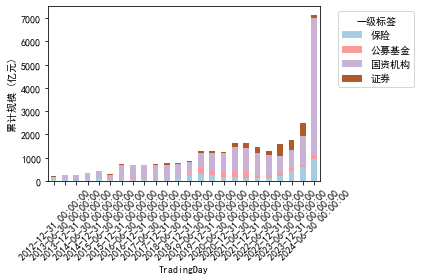

In [239]:
value_analysispivot_df = value_analysis.pivot_table(values='拥有规模存量', index='TradingDay', columns='一级标签', aggfunc='sum')
plt.figure(figsize=(12, 8))
value_analysispivot_df.plot(kind='bar', stacked=True, colormap='Paired')
plt.xlabel('TradingDay')
plt.ylabel('累计规模 (亿元)')
plt.xticks(rotation=45)
plt.legend(title='一级标签', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [240]:
fourcash=pd.concat([baoxiantotalcash,zhengquantotalcash,jijintotalcash,guoyoutotalcash],axis=1)
fourcash.columns=['保险总资金变化亿元','证券总资金变化亿元','公募基金资金变化亿元','国资机构资金变化亿元']
fourcash.index=value_analysispivot_df.index[-len(fourcash):]
fourcash.fillna(0,inplace=True)
fourcash

,保险总资金变化亿元,证券总资金变化亿元,公募基金资金变化亿元,国资机构资金变化亿元
TradingDay,,,,
2015-12-31,-22.616566,0.041041,-33.066899,535.762562
2016-06-30,42.361322,-5.420003,41.608894,-0.301954
2016-12-31,-11.753055,-1.082840,-36.550661,-0.654704
2017-06-30,-29.128788,12.487183,-1.105769,1.709163
2017-12-31,-41.042441,36.864754,-11.766384,-0.786732
2018-06-30,134.828801,-20.196823,6.937236,0.405197
2018-12-31,135.963908,16.864714,75.298852,0.932284
2019-06-30,27.231362,12.942924,118.252613,26.970021
2019-12-31,-87.154346,12.627299,-70.401573,65.506002


In [241]:
value_analysispivot_df.columns=['保险规模存量','公募基金规模存量','国资机构规模存量','证券规模存量'] 
value_analysispivot_df

,保险规模存量,公募基金规模存量,国资机构规模存量,证券规模存量
TradingDay,,,,
2012-12-31,168.315360,2.821065,0.178139,23.965907
2013-06-30,99.095724,0.783680,149.455117,10.097386
2013-12-31,63.077225,30.925023,167.261721,12.209454
2014-06-30,80.567520,25.453236,215.993990,13.975076
2014-12-31,123.048836,45.108462,241.139110,37.920234
2015-06-30,94.905125,44.496024,105.327226,37.907794
2015-12-31,58.520040,4.239904,631.960091,33.134578
2016-06-30,93.136010,46.610725,537.166446,22.494978
2016-12-31,83.613488,12.310605,570.103624,21.155577


In [242]:
valuecash=pd.concat([fourcash,value_analysispivot_df],axis=1,join='inner')
valuecash

,保险总资金变化亿元,证券总资金变化亿元,公募基金资金变化亿元,国资机构资金变化亿元,保险规模存量,公募基金规模存量,国资机构规模存量,证券规模存量
TradingDay,,,,,,,,
2015-12-31,-22.616566,0.041041,-33.066899,535.762562,58.520040,4.239904,631.960091,33.134578
2016-06-30,42.361322,-5.420003,41.608894,-0.301954,93.136010,46.610725,537.166446,22.494978
2016-12-31,-11.753055,-1.082840,-36.550661,-0.654704,83.613488,12.310605,570.103624,21.155577
2017-06-30,-29.128788,12.487183,-1.105769,1.709163,58.001043,12.589446,619.922477,35.958638
2017-12-31,-41.042441,36.864754,-11.766384,-0.786732,20.223453,1.766795,669.782794,77.120182
2018-06-30,134.828801,-20.196823,6.937236,0.405197,139.089813,7.858940,582.922903,49.196386
2018-12-31,135.963908,16.864714,75.298852,0.932284,236.818312,73.949115,509.839969,56.028276
2019-06-30,27.231362,12.942924,118.252613,26.970021,320.430240,218.505202,671.701779,85.195101
2019-12-31,-87.154346,12.627299,-70.401573,65.506002,257.814140,162.340089,771.853387,105.027606


In [243]:
baoxian=jigouholder[jigouholder['一级标签']=='保险']
baoxian[baoxian['HolderName'].str.contains('中国平安')]
pingantotalcash,pinganhangyecash=cashflowoutfunc(baoxian[baoxian['HolderName'].str.contains('中国平安')],hangye,price)
pingantotalcash

2016-03-31     21.046196
2016-08-31     -5.066795
2017-03-31    -14.461958
2017-08-31     -0.042512
2018-03-31     -1.961715
2018-08-31     55.944595
2019-03-31     26.158630
2019-08-31    -10.566709
2020-03-31      4.549862
2020-08-31     -3.106877
2021-03-31    -53.106155
2021-08-31     -9.030824
2022-03-31    -22.455050
2022-08-31      4.126060
2023-03-31     74.141737
2023-08-31    168.383895
2024-03-31     22.982819
2024-08-31     75.474607
dtype: float64

In [244]:
pinganhangyecash=fill_nan_after_first_non_na(pinganhangyecash)
pinganhangyecash

四级分类,000001,000010,000016,000300,000688,000698,000852,000903,000905,000906,...,399293,399303,399330,399673,399850,716567,930050,931643,932000,XIN9
TradingDay,,,,,,,,,,,,,,,,,,,,,
2016-03-31,NaN,NaN,1.586997,18.125888,NaN,NaN,NaN,NaN,0.485826,NaN,...,NaN,NaN,2.793926,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-08-31,NaN,NaN,-0.019655,-2.780970,NaN,NaN,NaN,NaN,-0.513843,NaN,...,NaN,NaN,-1.242857,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-03-31,NaN,NaN,-0.070027,-13.497804,NaN,NaN,NaN,NaN,-0.026508,NaN,...,NaN,NaN,-2.153563,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-31,NaN,NaN,-0.023847,1.519910,NaN,NaN,NaN,NaN,-0.321015,NaN,...,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-31,NaN,NaN,-1.683829,-1.730225,NaN,NaN,NaN,NaN,1.855521,NaN,...,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-08-31,NaN,NaN,0.000000,35.709642,NaN,NaN,NaN,NaN,15.481726,NaN,...,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-03-31,NaN,NaN,2.723814,21.431399,NaN,NaN,NaN,NaN,2.707893,NaN,...,NaN,NaN,0.516874,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-08-31,NaN,NaN,-2.963502,-4.653928,NaN,NaN,NaN,NaN,-2.910795,NaN,...,NaN,NaN,0.044376,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-03-31,NaN,NaN,0.000000,-1.166410,NaN,NaN,NaN,NaN,4.400035,NaN,...,NaN,NaN,-0.705029,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [245]:
zgrenshoutotalcash,zgrenshouhangyecash=cashflowoutfunc(baoxian[baoxian['HolderName'].str.contains('中国人寿')],hangye,price)
zgrenshoutotalcash

2016-03-31     -1.205501
2016-08-31     32.535514
2017-03-31     13.669642
2017-08-31    -19.176142
2018-03-31    -34.973544
2018-08-31     21.382816
2019-03-31     92.221372
2019-08-31     -8.367667
2020-03-31    -59.536565
2020-08-31    -52.549633
2021-03-31     -4.027135
2021-08-31     -4.567605
2022-03-31     -7.121561
2022-08-31     13.228171
2023-03-31      4.590642
2023-08-31     16.854374
2024-03-31    154.099714
2024-08-31    225.302049
dtype: float64

In [246]:
zgrenshouhangyecash=fill_nan_after_first_non_na(zgrenshouhangyecash)
zgrenshouhangyecash

四级分类,000001,000010,000016,000300,000688,000698,000852,000903,000905,000906,...,399005,399006,399303,399330,399673,399850,716567,930050,931643,932000
TradingDay,,,,,,,,,,,,,,,,,,,,,
2016-03-31,NaN,-4.293612,NaN,-1.780037,NaN,NaN,NaN,NaN,4.542962,NaN,...,NaN,1.086307,NaN,-0.761121,NaN,NaN,NaN,NaN,NaN,NaN
2016-08-31,NaN,0.534734,1.625839,9.079485,NaN,NaN,NaN,NaN,12.640906,NaN,...,1.405849,7.248700,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2017-03-31,NaN,-1.866066,19.475197,5.240020,NaN,NaN,NaN,NaN,-12.168991,NaN,...,-0.510515,2.339938,NaN,0.852013,0.308046,NaN,NaN,NaN,NaN,NaN
2017-08-31,NaN,0.000000,-16.219193,-6.746156,NaN,NaN,NaN,NaN,5.092174,NaN,...,-0.930569,-0.300252,NaN,0.185481,-0.257627,NaN,NaN,NaN,NaN,NaN
2018-03-31,NaN,0.000000,-2.976918,-13.443413,NaN,NaN,NaN,NaN,-8.194575,NaN,...,0.000000,-9.144721,NaN,-1.213917,0.000000,NaN,NaN,NaN,NaN,NaN
2018-08-31,NaN,0.000000,-0.501519,6.428655,NaN,NaN,NaN,NaN,4.481911,NaN,...,0.000000,7.027388,NaN,0.000000,3.946381,NaN,NaN,NaN,NaN,NaN
2019-03-31,NaN,0.000000,14.344058,40.135520,NaN,NaN,0.070853,NaN,16.726538,NaN,...,0.000000,8.770014,NaN,0.000000,11.972894,NaN,0.201494,NaN,NaN,NaN
2019-08-31,NaN,0.000000,-18.969093,-26.842781,NaN,NaN,-0.077167,NaN,10.892151,NaN,...,0.000000,25.070904,NaN,0.000000,1.782394,NaN,-0.224075,NaN,NaN,NaN
2020-03-31,NaN,0.000000,0.000000,-9.189781,NaN,NaN,0.000000,0.209546,-14.338903,NaN,...,0.000000,-24.438732,NaN,0.000000,-11.778695,NaN,0.000000,NaN,NaN,NaN


In [247]:
zhengquan=jigouholder[jigouholder['一级标签']=='证券']

In [248]:
zhongxintotalcash,zhongxinhangyecash=cashflowoutfunc(zhengquan[zhengquan['HolderName'].str.contains('中信证券')],hangye,price)
zhongxintotalcash

2016-03-31     -2.702990
2016-08-31     -2.539362
2017-03-31     -0.267497
2017-08-31      0.760897
2018-03-31     12.652341
2018-08-31    -10.920770
2019-03-31      6.148378
2019-08-31      3.156433
2020-03-31     -0.157539
2020-08-31     -7.347274
2021-03-31     22.239209
2021-08-31    -20.733327
2022-03-31     27.953329
2022-08-31    -24.284340
2023-03-31    108.564745
2023-08-31    -98.813151
2024-03-31     89.329517
2024-08-31   -109.383784
dtype: float64

In [249]:
zhongxinhangyecash=fill_nan_after_first_non_na(zhongxinhangyecash)
zhongxinhangyecash

四级分类,000001,000009,000010,000016,000043,000300,000688,000698,000852,000903,...,399624,399673,399850,704843,716567,930050,930903,931643,932000,XIN9
TradingDay,,,,,,,,,,,,,,,,,,,,,
2016-03-31,NaN,NaN,0.320137,-4.891113,NaN,2.177966,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-08-31,NaN,NaN,-0.266979,-0.028907,NaN,-2.294872,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-03-31,NaN,NaN,0.000000,-0.008162,NaN,-0.180263,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-31,NaN,NaN,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-31,NaN,NaN,0.000000,6.861820,NaN,5.790259,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.015511
2018-08-31,NaN,NaN,0.000000,-5.216429,NaN,-5.825022,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.651442,NaN,NaN,NaN,NaN,-0.005488
2019-03-31,NaN,NaN,0.000000,5.252121,NaN,0.518959,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.332163,NaN,NaN,NaN,NaN,0.002411
2019-08-31,0.055881,NaN,0.000000,-3.770415,NaN,6.595656,NaN,NaN,0.034924,NaN,...,NaN,NaN,NaN,NaN,-0.344135,NaN,NaN,NaN,NaN,-0.007562
2020-03-31,0.022990,NaN,0.234764,-3.226234,NaN,1.077397,NaN,NaN,-0.036294,0.075712,...,NaN,NaN,NaN,0.011472,-0.445096,NaN,NaN,NaN,NaN,0.015698


In [250]:
zhaoshangtotalcash,zhaoshanghangyecash=cashflowoutfunc(zhengquan[zhengquan['HolderName'].str.contains('招商')],hangye,price)
zhaoshangtotalcash

2016-03-31    -6.597545
2016-08-31    -0.067905
2018-03-31     3.598023
2018-08-31    -3.021226
2019-03-31     0.909147
2019-08-31     1.227818
2020-03-31     0.704267
2020-08-31    -0.411796
2021-03-31    -1.367338
2021-08-31    -0.905943
2022-03-31    13.994457
2022-08-31    -5.914323
2023-03-31    25.380031
2023-08-31   -31.502493
2024-03-31    18.399358
2024-08-31   -12.396236
dtype: float64

In [251]:
zhaoshanghangyecash=fill_nan_after_first_non_na(zhaoshanghangyecash)
zhaoshanghangyecash

四级分类,000001,000010,000016,000043,000300,000688,000698,000852,000903,000905,...,399303,399330,399673,399850,716567,930050,930903,931643,932000,XIN9
TradingDay,,,,,,,,,,,,,,,,,,,,,
2016-03-31,NaN,NaN,-6.570547,NaN,0.019464,NaN,NaN,NaN,NaN,0.002355,...,NaN,NaN,NaN,NaN,-0.048817,NaN,NaN,NaN,NaN,NaN
2016-08-31,NaN,NaN,-0.051213,NaN,-0.016614,NaN,NaN,NaN,NaN,-0.002077,...,NaN,NaN,NaN,NaN,0.002000,NaN,NaN,NaN,NaN,NaN
2018-03-31,NaN,3.624474,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,...,NaN,NaN,NaN,NaN,-0.026452,NaN,NaN,NaN,NaN,NaN
2018-08-31,NaN,-3.704128,0.000000,NaN,0.090777,NaN,NaN,NaN,NaN,0.000000,...,NaN,0.245397,NaN,NaN,0.315997,NaN,NaN,NaN,NaN,0.008926
2019-03-31,NaN,0.002397,0.064883,0.018579,0.015069,NaN,NaN,NaN,NaN,0.000000,...,NaN,0.221819,NaN,NaN,0.582226,NaN,NaN,NaN,NaN,-0.001700
2019-08-31,0.027629,-0.086269,1.482161,0.010560,0.031929,NaN,NaN,0.032536,NaN,0.185561,...,NaN,-0.089698,NaN,NaN,-0.620823,NaN,NaN,NaN,NaN,0.000138
2020-03-31,0.018840,0.029569,-1.351392,-0.013995,0.039915,NaN,NaN,-0.005095,NaN,2.336426,...,NaN,-0.420415,NaN,NaN,-0.131155,NaN,NaN,NaN,NaN,0.028553
2020-08-31,-0.036912,0.027537,0.227997,-0.005736,0.360339,NaN,NaN,0.034139,NaN,-0.781671,...,NaN,0.071530,NaN,NaN,-0.172033,NaN,NaN,NaN,NaN,-0.022427
2021-03-31,0.029258,-0.067154,-0.578465,-0.008831,-0.451841,0.937330,NaN,-0.082976,NaN,-1.865492,...,NaN,0.021164,NaN,NaN,0.025152,NaN,NaN,NaN,NaN,0.000923


In [252]:
huaxiatotalcash,huaxiahangyecash=cashflowoutfunc(jijin[jijin['HolderName'].str.contains('华夏基金')],hangye,price)
huaxiatotalcash

2020-03-31     9.938014
2020-08-31     8.096466
2021-03-31    38.712341
2021-08-31   -18.010867
2022-03-31   -26.419239
2022-08-31   -20.263519
2023-03-31    -2.957181
2023-08-31     5.154638
2024-03-31     0.324396
2024-08-31     0.529185
dtype: float64

In [253]:
huaxiahangyecash=fill_nan_after_first_non_na(huaxiahangyecash)
huaxiahangyecash

四级分类,000001,000016,000300,000852,000905,133333,399005,399006,399330,399673,716567,932000
TradingDay,,,,,,,,,,,,
2020-03-31,0.027395,NaN,7.740324,NaN,3.495049,1.469810,NaN,-3.823750,0.917433,NaN,0.111753,NaN
2020-08-31,-0.028289,1.289409,3.836735,NaN,1.213144,-2.660286,0.294383,1.631579,1.885060,0.754283,-0.119552,NaN
2021-03-31,0.000000,12.585768,22.109649,NaN,3.422028,0.598645,-0.375337,-1.266672,1.631378,-2.148007,2.154889,NaN
2021-08-31,0.000000,-15.094693,-9.600015,0.336681,1.620245,-0.107558,0.000000,-0.928222,4.250358,0.952701,0.559635,NaN
2022-03-31,0.000000,0.000000,-7.525396,-0.400329,-5.512661,-0.592810,0.000000,-0.039275,-5.735212,-3.562883,-3.050671,NaN
2022-08-31,0.000000,0.000000,-13.214331,0.000000,-6.270490,0.000000,0.000000,-0.023770,0.000000,-0.754929,0.000000,NaN
2023-03-31,0.000000,0.000000,-4.474615,1.517434,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
2023-08-31,0.000000,0.000000,0.000000,-2.129045,7.283682,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
2024-03-31,0.000000,0.000000,0.000575,0.000000,0.292310,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.031511


In [254]:
boshitotalcash,boshihangyecash=cashflowoutfunc(jijin[jijin['HolderName'].str.contains('博时')],hangye,price)
boshitotalcash

2018-08-31    1.393569
2019-03-31    1.123437
2019-08-31    0.271381
2020-08-31   -3.556276
2021-03-31    0.198796
2021-08-31   -0.207049
2022-03-31    2.221495
2022-08-31   -1.857461
2023-03-31   -0.184174
2023-08-31    0.129418
dtype: float64

In [255]:
boshihangyecash=fill_nan_after_first_non_na(boshihangyecash)
boshihangyecash

四级分类,000016,000300,000903,000905,399006,931643
TradingDay,,,,,,
2018-08-31,1.393569,NaN,NaN,NaN,NaN,NaN
2019-03-31,1.123437,NaN,NaN,NaN,NaN,NaN
2019-08-31,0.271381,NaN,NaN,NaN,NaN,NaN
2020-08-31,-3.642894,NaN,NaN,NaN,0.086618,NaN
2021-03-31,0.000000,NaN,NaN,0.326477,-0.127680,NaN
2021-08-31,0.000000,NaN,NaN,-0.207049,0.000000,NaN
2022-03-31,0.000000,2.002882,NaN,0.067756,0.000000,0.150858
2022-08-31,0.000000,-1.778170,0.099666,-0.061464,0.000000,-0.117494
2023-03-31,0.000000,0.030997,-0.092260,-0.135884,0.012973,0.000000


In [256]:
shiyoutotalcash,shiyouhangyecash=cashflowoutfunc(guoyou[guoyou['HolderName'].str.contains('中国石油')],hangye,price)
shiyoutotalcash

2016-08-31    -0.301954
2017-03-31    -0.021681
2017-08-31     0.589313
2018-03-31    -0.605219
2018-08-31     1.517699
2019-03-31    -1.207691
2019-08-31     0.149841
2020-03-31    30.212445
2020-08-31     0.009987
2021-03-31    -9.766222
2021-08-31     1.257404
2022-03-31    -1.387968
2023-03-31     0.331986
2023-08-31    -0.332018
2024-03-31     0.067148
2024-08-31     0.868939
dtype: float64

In [257]:
shiyouhangyecash=fill_nan_after_first_non_na(shiyouhangyecash)
shiyouhangyecash

四级分类,000009,000010,000300,000688,000905,133333,399006,399673,930050,XIN9
TradingDay,,,,,,,,,,
2017-03-31,0.010083,NaN,NaN,NaN,NaN,NaN,-0.312037,NaN,NaN,NaN
2017-08-31,-0.021681,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
2018-03-31,0.000000,0.205243,NaN,NaN,NaN,NaN,0.384070,NaN,NaN,NaN
2018-08-31,0.000000,-0.230932,NaN,NaN,NaN,NaN,-0.374287,NaN,NaN,NaN
2019-03-31,0.000000,0.000000,NaN,NaN,NaN,NaN,0.911965,0.605734,NaN,NaN
2019-08-31,-0.007469,0.000000,NaN,NaN,NaN,NaN,-0.735129,-0.465093,NaN,NaN
2020-03-31,-0.013354,0.000000,NaN,NaN,NaN,0.163196,0.000000,0.000000,NaN,NaN
2020-08-31,0.000000,0.000000,30.385527,NaN,NaN,-0.173083,0.000000,0.000000,NaN,NaN
2021-03-31,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,0.009987


In [258]:
huijintotalcash,huijinhangyecash=cashflowoutfunc(guoyou[guoyou['HolderName'].str.contains('中央汇金')],hangye,price)
huijintotalcash

2016-03-31     534.677476
2019-03-31       2.215530
2019-08-31      25.431564
2020-03-31      36.726629
2020-08-31      18.546695
2021-03-31      28.784373
2021-08-31      34.530158
2022-03-31     -22.392664
2022-08-31      -8.569400
2023-03-31      14.164505
2023-08-31       5.256022
2024-03-31     537.647229
2024-08-31    4728.549876
dtype: float64

In [259]:
huijinhangyecash=fill_nan_after_first_non_na(huijinhangyecash)
huijinhangyecash

四级分类,000010,000016,000300,000688,000852,000905,000906,133333,399005,399006,399330,399673,716567
TradingDay,,,,,,,,,,,,,
2018-08-31,137.388559,137.772916,131.396738,NaN,NaN,127.566139,NaN,NaN,NaN,NaN,0.553124,NaN,NaN
2019-03-31,0.000000,0.000000,1.107990,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,1.107540,NaN,NaN
2019-08-31,0.000000,0.000000,10.238516,NaN,NaN,0.000000,NaN,NaN,NaN,5.418852,9.774196,NaN,NaN
2020-03-31,0.000000,0.000000,10.870547,NaN,NaN,2.698102,12.865147,NaN,NaN,0.183592,10.109240,NaN,NaN
2020-08-31,0.000000,7.291235,5.641496,NaN,NaN,2.086453,0.000000,NaN,0.294383,1.915560,0.563286,0.754283,NaN
2021-03-31,0.000000,-1.531520,20.592905,NaN,NaN,3.422028,0.000000,0.598645,-0.375337,-0.872834,5.859531,-1.063935,2.154889
2021-08-31,0.000000,-3.619830,-2.487751,NaN,NaN,4.496946,0.000000,-0.107558,0.000000,-0.883254,32.593897,3.978073,0.559635
2022-03-31,0.000000,-3.601148,-8.369843,NaN,NaN,4.078752,0.000000,-0.592810,0.000000,0.000000,-7.294060,-3.562883,-3.050671
2022-08-31,0.000000,0.000000,-0.706092,NaN,NaN,-8.782215,0.000000,0.000000,0.000000,0.777347,0.896488,-0.754929,0.000000


2023年末截面情况

In [260]:
kuanjibiaoqian=pd.read_excel(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\前10大打标签\宽基ETF标签.xlsx')
kuanjibiaoqian

,HolderName,简称,标签
0,中兵财富资产管理有限责任公司-中兵资产白鹿1号平衡私募证券投资基金,中兵财富资产管理有限公司,私募基金
1,海南盛冠达私募基金管理有限公司－盛冠达试金石5号私募证券投资基金,海南盛冠达私募基金有限公司,私募基金
2,博时基金－招商银行－博时基金汇利1号集合资产管理计划,博时基金有限公司,公募基金
3,上海橡杉资产管理有限公司－橡杉量化套利八号私募证券投资基金,上海橡杉资产有限公司,私募基金
4,安邦人寿保险股份有限公司-保守型投资组合,安邦人寿保险有限公司,保险
...,...,...,...
411,中信中证资本管理有限公司,中信中证资本有限公司,私募基金
412,中央汇金投资有限责任公司,中央汇金投资有限公司,国资机构
413,中央汇金资产管理有限责任公司,中央汇金资产管理有限公司,国资机构
414,中英人寿保险有限公司,中英人寿保险有限公司,保险


In [261]:
mergedf=pd.merge(Top_jigou,kuanjibiaoqian,on='HolderName')

In [262]:
end2022=mergedf[mergedf['TradingDay']=='2022-12-31']
end2022

,证券代码,TradingDay,四级分类,市值亿元,InfoPublDate,HoldingVolume,HolderName,HoldingRatio,购买市值亿元,HolderType,简称,标签
72,159949.OF,2022-12-31,399673,111.368517,2023-03-30,552585921.0,中国人寿保险股份有限公司,0.050982,5.677790,机构holder,中国人寿保险有限公司,保险
94,510050.OF,2022-12-31,000016,582.966459,2023-03-30,224543000.0,中国人寿保险股份有限公司,0.010196,5.943926,机构holder,中国人寿保险有限公司,保险
129,510330.OF,2022-12-31,000300,249.084844,2023-03-30,58220268.0,中国人寿保险股份有限公司,0.009202,2.292079,机构holder,中国人寿保险有限公司,保险
149,510580.OF,2022-12-31,000905,20.464954,2023-03-30,72800000.0,中国人寿保险股份有限公司,0.024819,0.507920,机构holder,中国人寿保险有限公司,保险
163,512500.OF,2022-12-31,000905,41.769337,2023-03-30,123721624.0,中国人寿保险股份有限公司,0.092661,3.870389,机构holder,中国人寿保险有限公司,保险
...,...,...,...,...,...,...,...,...,...,...,...,...
6754,588090.OF,2022-12-31,000688,35.466710,2023-03-31,21799963.0,招商证券资管－国新投资有限公司－招证资管国新2号单一资产管理计划,0.006104,0.216489,机构holder,招商证券资管有限公司,证券
6763,588180.OF,2022-12-31,000688,18.373982,2023-03-31,400023000.0,中国太平洋人寿保险股份有限公司－保额分红,0.134785,2.476537,机构holder,中国太平洋人寿保险有限公司,保险
6769,588180.OF,2022-12-31,000688,18.373982,2023-03-31,159156300.0,中国太平洋保险(集团)股份有限公司－集团本级－自有资金－012G－ZY001沪,0.053627,0.985342,机构holder,中国太平洋保险集团有限公司,保险
6775,588180.OF,2022-12-31,000688,18.373982,2023-03-31,128833760.0,湖州海煜股权投资合伙企业(有限合伙),0.043410,0.797615,机构holder,湖州海煜股权投资合伙企业有限合伙有限公司,私募基金


In [263]:
gejigou2022=end2022.groupby('标签').sum(numeric_only=True)['购买市值亿元'].sort_values(ascending=False)
gejigou2022

标签
国资机构    741.330441
证券      560.945066
保险      207.474936
银行       61.987686
公募基金     59.588501
私募基金     26.827470
信托       12.967138
外资机构      4.764405
财务公司      1.570190
期货        0.864655
Name: 购买市值亿元, dtype: float64

In [264]:
mergedf=pd.merge(Top_jigou,kuanjibiaoqian,on='HolderName')
end2023=mergedf[mergedf['TradingDay']=='2023-12-31']
end2023

,证券代码,TradingDay,四级分类,市值亿元,InfoPublDate,HoldingVolume,HolderName,HoldingRatio,购买市值亿元,HolderType,简称,标签
7,159628.OF,2023-12-31,399303,22.146716,2024-03-29,95000000.0,中国人寿保险股份有限公司,0.0414,0.916874,机构holder,中国人寿保险有限公司,保险
9,159629.OF,2023-12-31,000852,51.763522,2024-03-29,236470039.0,中国人寿保险股份有限公司,0.1081,5.595637,机构holder,中国人寿保险有限公司,保险
11,159633.OF,2023-12-31,000852,29.651963,2024-03-29,102217900.0,中国人寿保险股份有限公司,0.0814,2.413670,机构holder,中国人寿保险有限公司,保险
13,159681.OF,2023-12-31,399673,8.365876,2024-03-28,8485400.0,中国人寿保险股份有限公司,0.0078,0.065254,机构holder,中国人寿保险有限公司,保险
15,159682.OF,2023-12-31,399673,18.200677,2024-03-29,24020500.0,中国人寿保险股份有限公司,0.0100,0.182007,机构holder,中国人寿保险有限公司,保险
...,...,...,...,...,...,...,...,...,...,...,...,...
6792,588220.OF,2023-12-31,000698,77.015794,2024-03-28,95994700.0,鹏华基金管理有限公司,0.0122,0.939593,机构holder,鹏华基金有限公司,公募基金
6798,588280.OF,2023-12-31,000688,2.469547,2024-03-27,3049000.0,陕西泰恒融资租赁有限公司,0.0076,0.018769,机构holder,陕西泰恒融资租赁有限公司,私募基金
6800,588280.OF,2023-12-31,000688,2.469547,2024-03-27,3100000.0,深圳经纶纵横投资管理有限公司－经纶纵横芳华1号私募证券投资基金,0.0077,0.019016,机构holder,深圳经纶纵横投资有限公司,私募基金
6806,588370.OF,2023-12-31,000688,2.087223,2024-03-29,27000000.0,长城人寿保险股份有限公司-自有资金,0.1088,0.227090,机构holder,长城人寿保险有限公司,保险


In [265]:
gejigou2023=end2023.groupby('标签').sum(numeric_only=True)['购买市值亿元'].sort_values(ascending=False)
gejigou2023

标签
国资机构    1198.287950
证券       579.291936
保险       567.634496
公募基金      49.718516
私募基金      18.479013
外资机构      12.987425
信托         3.289965
银行         2.690738
财务公司       2.281409
期货         0.447216
Name: 购买市值亿元, dtype: float64

In [266]:
gejigou2023s=pd.concat([gejigou2022,gejigou2023],axis=1)
gejigou2023s.columns=['2022年末拥有规模','2023年末拥有规模']
# gejigou2023s=gejigou2023s[0:4]
gejigou2023s

,2022年末拥有规模,2023年末拥有规模
标签,,
国资机构,741.330441,1198.287950
证券,560.945066,579.291936
保险,207.474936,567.634496
银行,61.987686,2.690738
公募基金,59.588501,49.718516
私募基金,26.827470,18.479013
信托,12.967138,3.289965
外资机构,4.764405,12.987425
财务公司,1.570190,2.281409


In [267]:
jijin[jijin['TradingDay']=='2023-12-31']['购买市值亿元'].sum()  #十分接近

95.3151028046194

In [268]:
guoyou[guoyou['TradingDay']=='2023-12-31']['购买市值亿元'].sum()#很接近

1232.7410386702252

In [269]:
jingque=end2023.groupby(['标签','简称','TradingDay']).sum(numeric_only=True)['购买市值亿元'].reset_index()
jingque

,标签,简称,TradingDay,购买市值亿元
0,保险,中华联合财产保险有限公司,2023-12-31,1.136137
1,保险,中国人寿保险有限公司,2023-12-31,151.575589
2,保险,中国人寿保险集团公司有限公司,2023-12-31,2.252075
3,保险,中国人寿再保险有限公司,2023-12-31,7.020816
4,保险,中国太平洋人寿保险有限公司,2023-12-31,6.141475
...,...,...,...,...
160,银行,中国银行有限公司,2023-12-31,1.179183
161,银行,光大银行有限公司,2023-12-31,0.131950
162,银行,兴银理财有限公司,2023-12-31,0.050243
163,银行,吉林银行有限公司,2023-12-31,0.424150


In [270]:
eachtop5=jingque.groupby('标签', group_keys=False).apply(lambda x: x.sort_values('购买市值亿元', ascending=False).head(5))#每一个列表最多的5个
eachtop5

,标签,简称,TradingDay,购买市值亿元
7,保险,中国平安人寿保险有限公司,2023-12-31,247.755812
1,保险,中国人寿保险有限公司,2023-12-31,151.575589
15,保险,大家人寿保险有限公司,2023-12-31,43.957674
25,保险,泰康人寿保险有限公司,2023-12-31,28.935257
14,保险,友邦人寿保险有限公司,2023-12-31,26.260938
32,信托,平安信托有限公司,2023-12-31,3.289965
40,公募基金,易方达基金有限公司,2023-12-31,24.922836
34,公募基金,南方基金有限公司,2023-12-31,12.875329
33,公募基金,华夏基金有限公司,2023-12-31,6.768336
43,公募基金,银华基金有限公司,2023-12-31,2.966191


In [271]:
buy=pd.merge(end2023.groupby(['标签','简称','证券代码']).sum(numeric_only=True)[['购买市值亿元']].reset_index(),end2023[['证券代码','市值亿元']].drop_duplicates(),on='证券代码')
buy['购买比例']=buy['购买市值亿元']/buy['市值亿元']
buyinfo=buy.groupby(['标签','简称','证券代码']).sum(numeric_only=True)[['购买市值亿元','购买比例']].reset_index()
buyinfo

,标签,简称,证券代码,购买市值亿元,购买比例
0,保险,中华联合财产保险有限公司,510760.OF,0.048273,0.0052
1,保险,中华联合财产保险有限公司,515380.OF,0.331384,0.0079
2,保险,中华联合财产保险有限公司,588090.OF,0.442620,0.0091
3,保险,中华联合财产保险有限公司,588460.OF,0.313861,0.0461
4,保险,中国人寿保险有限公司,159628.OF,0.916874,0.0414
...,...,...,...,...,...
976,银行,中国银行有限公司,561550.OF,0.351189,0.0519
977,银行,光大银行有限公司,561550.OF,0.131950,0.0195
978,银行,兴银理财有限公司,516300.OF,0.050243,0.0360
979,银行,吉林银行有限公司,588060.OF,0.424150,0.0126


In [272]:
buyinfos=pd.merge(buyinfo,buyinfo.groupby(['标签','简称']).sum(numeric_only=True)['购买市值亿元'].reset_index(),on=['标签','简称'])
buyinfos.rename(columns={'购买市值亿元_x':'买了该基金市值亿元','购买市值亿元_y':'该机构买的所有基金总市值亿元和'},inplace=True)
buyinfos['买的该基金占你总基金中的持仓比例']=buyinfos['买了该基金市值亿元']/buyinfos['该机构买的所有基金总市值亿元和']
buyinfos['购买比例*持仓比例']=buyinfos['购买比例']*buyinfos['买的该基金占你总基金中的持仓比例']
buyinfos=pd.merge(buyinfos,end2023[['证券代码','市值亿元']].drop_duplicates(),on='证券代码')
buyinfos
# buyinfos.groupby('标签', group_keys=False).apply(lambda x: x.sort_values('该机构买的所有基金总市值亿元和', ascending=False).head(100))

,标签,简称,证券代码,买了该基金市值亿元,购买比例,该机构买的所有基金总市值亿元和,买的该基金占你总基金中的持仓比例,购买比例*持仓比例,市值亿元
0,保险,中华联合财产保险有限公司,510760.OF,0.048273,0.0052,1.136137,0.042488,0.000221,9.283224
1,保险,中国平安人寿保险有限公司,510760.OF,0.953387,0.1027,247.755812,0.003848,0.000395,9.283224
2,保险,中国平安财产保险有限公司,510760.OF,0.065911,0.0071,3.419933,0.019273,0.000137,9.283224
3,外资机构,BARCLAYSBANKPLC有限公司,510760.OF,0.062198,0.0067,0.803827,0.077377,0.000518,9.283224
4,证券,中信建投证券有限公司,510760.OF,0.083549,0.0090,13.227888,0.006316,0.000057,9.283224
...,...,...,...,...,...,...,...,...,...
976,证券,海通证券有限公司,512360.OF,0.019117,0.0265,66.960550,0.000285,0.000008,0.721387
977,证券,华泰证券有限公司,560590.OF,0.029379,0.1494,25.464792,0.001154,0.000172,0.196647
978,证券,招商证券有限公司,560590.OF,0.051875,0.2638,26.794779,0.001936,0.000511,0.196647
979,证券,方正证券有限公司,510550.OF,0.016583,0.0891,5.798094,0.002860,0.000255,0.186112


In [273]:
totalnumber=end2023.groupby(['标签','简称']).count()['证券代码'].reset_index()
totalnumber.rename(columns={'证券代码':'总购买基金个数'},inplace=True)
totalnumber

,标签,简称,总购买基金个数
0,保险,中华联合财产保险有限公司,4
1,保险,中国人寿保险有限公司,32
2,保险,中国人寿保险集团公司有限公司,4
3,保险,中国人寿再保险有限公司,2
4,保险,中国太平洋人寿保险有限公司,2
...,...,...,...
160,银行,中国银行有限公司,5
161,银行,光大银行有限公司,1
162,银行,兴银理财有限公司,1
163,银行,吉林银行有限公司,1


In [274]:
eachnumber=end2023.groupby(['标签','简称','四级分类']).count()['证券代码'].reset_index()
eachnumber.rename(columns={'证券代码':'该行业购买个数'},inplace=True)
eachnumber

,标签,简称,四级分类,该行业购买个数
0,保险,中华联合财产保险有限公司,000001,1
1,保险,中华联合财产保险有限公司,000300,1
2,保险,中华联合财产保险有限公司,000688,2
3,保险,中国人寿保险有限公司,000300,4
4,保险,中国人寿保险有限公司,000688,3
...,...,...,...,...
483,银行,中国银行有限公司,000905,3
484,银行,光大银行有限公司,000905,1
485,银行,兴银理财有限公司,000852,1
486,银行,吉林银行有限公司,000688,1


In [275]:
numbers=pd.merge(eachnumber,totalnumber,on=['标签','简称'])
numbers

,标签,简称,四级分类,该行业购买个数,总购买基金个数
0,保险,中华联合财产保险有限公司,000001,1,4
1,保险,中华联合财产保险有限公司,000300,1,4
2,保险,中华联合财产保险有限公司,000688,2,4
3,保险,中国人寿保险有限公司,000300,4,32
4,保险,中国人寿保险有限公司,000688,3,32
...,...,...,...,...,...
483,银行,中国银行有限公司,000905,3,5
484,银行,光大银行有限公司,000905,1,1
485,银行,兴银理财有限公司,000852,1,1
486,银行,吉林银行有限公司,000688,1,1


In [276]:
numbertop=numbers.groupby('标签', group_keys=False).apply(lambda x: x.sort_values('总购买基金个数', ascending=False))
numbertop

,标签,简称,四级分类,该行业购买个数,总购买基金个数
31,保险,中国平安人寿保险有限公司,399006,8,87
22,保险,中国平安人寿保险有限公司,000010,3,87
37,保险,中国平安人寿保险有限公司,931643,9,87
36,保险,中国平安人寿保险有限公司,716567,2,87
35,保险,中国平安人寿保险有限公司,399673,4,87
...,...,...,...,...,...
480,银行,中国民生银行有限公司,000300,1,1
484,银行,光大银行有限公司,000905,1,1
485,银行,兴银理财有限公司,000852,1,1
486,银行,吉林银行有限公司,000688,1,1


In [277]:
excel_writer = pd.ExcelWriter(r'd:\Users\Administrator\Desktop\国金\ETF数据更新\ETF 24\ETF\底稿.xlsx', engine='openpyxl', mode='a')
sigejigou.to_excel(excel_writer, sheet_name='宽基主题四大机构时序总表', index=False)
valuecash.to_excel(excel_writer, sheet_name='宽基主题四大机构时序资金已经规模变化数据')
baoxianhangyecash.to_excel(excel_writer, sheet_name='保险细分宽基资金')
pinganhangyecash.to_excel(excel_writer, sheet_name='中国平安细分宽基资金')
zgrenshouhangyecash.to_excel(excel_writer, sheet_name='中国人寿细分宽基资金')
zhengquanhangyecash.to_excel(excel_writer, sheet_name='证券细分宽基资金')
zhongxinhangyecash.to_excel(excel_writer, sheet_name='中信证券细分宽基资金')
zhaoshanghangyecash.to_excel(excel_writer, sheet_name='招商证券细分宽基资金')
jijinhangyecash.to_excel(excel_writer, sheet_name='基金细分宽基资金')
huaxiahangyecash.to_excel(excel_writer, sheet_name='华夏基金细分宽基资金')
boshihangyecash.to_excel(excel_writer, sheet_name='博时基金细分宽基资金')
guoyouhangyecash.to_excel(excel_writer, sheet_name='国资细分宽基资金')
shiyouhangyecash.to_excel(excel_writer, sheet_name='中国石油细分宽基资金')
huijinhangyecash.to_excel(excel_writer, sheet_name='中央汇金细分宽基资金')
end2023.to_excel(excel_writer, sheet_name='宽基2023年底截面所有机构总表', index=False)
gejigou2023.to_excel(excel_writer, sheet_name='宽基2023末规模总览')
gejigou2023s.to_excel(excel_writer, sheet_name='宽基四大机构年初末对比')
# jingque.to_excel(excel_writer, sheet_name='宽基2023末所有机构购买市值总表', index=False)
eachtop5.to_excel(excel_writer, sheet_name='宽基2023末所有机构中各自买的规模最多的top5', index=False)
buyinfos.to_excel(excel_writer, sheet_name='宽基各基金规模比例总览表', index=False)
numbers.to_excel(excel_writer, sheet_name='宽基2023末所有机构中买的基金个数总表', index=False)
# numbertop.to_excel(excel_writer, sheet_name='宽基2023末所有机构中依照分类对每一类降序排序', index=False)

In [278]:
excel_writer.save()
excel_writer.close()